# Analyse de la convergence technologique : Le véhicule électrique
## Étude de cas : H01M (Batteries) × B60L (Propulsion électrique)

---

## Contexte et objectif

Le véhicule électrique moderne est l'un des exemples les plus emblématiques
de convergence technologique des dernières décennies. Son émergence résulte
de la fusion de deux domaines technologiques historiquement distincts :

- **H01M** : Piles et accumulateurs électrochimiques (batteries lithium-ion,
  électrodes, électrolytes). Domaine issu de la chimie et de l'électrochimie.
- **B60L** : Propulsion électrique des véhicules (moteurs de traction,
  freinage régénératif, gestion de l'énergie). Domaine issu du génie mécanique
  et de l'ingénierie automobile.

Ces deux domaines ont co-évolué jusqu'à former un nouveau champ technologique
intégré — le véhicule électrique moderne — dont l'émergence industrielle
est généralement datée autour de **2012** (Tesla Model S, boom des VE).

## Démarche

**On ne cherche pas ici à valider que nos méthodes 'trouvent' 2012.**
On sait que la convergence a eu lieu. L'objectif est de documenter
comment chaque méthode caractérise ce processus :
quel signal donne-t-elle, à quel moment, et que nous apprend-elle
sur la nature de cette convergence ?

Ce faisant, on construit une **signature empirique de la convergence**
qu'on pourra ensuite reconnaître sur d'autres cas.

## Les 4 méthodes

1. **Centralité (Strength)** : mesure de l'importance structurelle d'un code
   dans le réseau de co-occurrences. Un code qui devient central est un code
   qui joue un rôle de pont entre domaines technologiques.

2. **Clustering dynamique** : identification des communautés technologiques
   stables. Deux codes qui convergent finissent par appartenir au même cluster
   absorbant.

3. **Corrélation temporelle** : synchronisation des cycles d'innovation.
   Deux domaines qui convergent innovent de plus en plus en même temps.

4. **Jaccard + Probabilités conditionnelles** : mesure directe de l'intensité
   et de la bilatéralité de la co-occurrence. Permet de distinguer une vraie
   convergence bilatérale d'une intégration unilatérale (General Purpose Technology).

## 0. Imports, paramètres et données

In [46]:
import pandas as pd
import numpy as np
import itertools
from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests, ccf
import networkx as nx
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
from scipy.stats import pearsonr
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# PALETTE DE COULEURS COHÉRENTE SUR TOUT LE NOTEBOOK
# ════════════════════════════════════════════════════════════════
# On utilise une palette sobre et lisible en noir et blanc aussi
C_H01M    = '#E07B39'   # orange  — batteries (H01M)
C_B60L    = '#2E86AB'   # bleu    — propulsion (B60L)
C_JACCARD = '#1B4332'   # vert foncé — Jaccard
C_RUPTURE = '#C0392B'   # rouge   — ruptures
C_EMERGE  = '#7F8C8D'   # gris    — date d'émergence connue
C_COMMUN  = '#8E44AD'   # violet  — voisins communs
C_POS     = '#A9DFBF'   # vert clair — corrélation positive
C_NEG     = '#F1948A'   # rouge clair — corrélation négative

# ════════════════════════════════════════════════════════════════
# PARAMÈTRES MÉTHODOLOGIQUES
# Chaque paramètre est justifié par un commentaire
# ════════════════════════════════════════════════════════════════

WINDOW       = 5
# Fenêtre glissante de 5 ans.
# Justification : suffisamment large pour lisser le bruit annuel
# des dépôts de brevets, suffisamment courte pour détecter
# des dynamiques de moyen terme (5 ans est standard dans la littérature
# sur les réseaux d'innovation : Acemoglu et al. 2016, Mariani et al. 2017).

SMOOTH_W     = 3
# Lissage des séries temporelles par moyenne mobile sur 3 ans.
# Justification : élimine les pics/creux ponctuels liés à des années
# de dépôt atypiques, sans déformer la tendance de fond.

K_CLUSTERS   = 10
# Nombre de clusters k-means.
# Justification : 10 clusters pour ~600 codes CPC4 donne des groupes
# de ~60 codes, suffisamment fins pour distinguer les domaines
# technologiques majeurs (chimie, électronique, mécanique, etc.).
# Testé en robustesse avec k=8 et k=12.

N_PCA        = 20
# Composantes PCA avant clustering.
# Justification : capture ~80% de la variance de la matrice de
# co-occurrence tout en réduisant le bruit des dimensions marginales.

N_NEIGHBORS  = 5
# Nombre de voisins affichés dans les ego-networks.
# Justification : les 10 voisins les plus forts donnent une image
# lisible du voisinage technologique sans surcharger le graphique.

CORR_WINDOW  = 5
# Fenêtre de la corrélation glissante.
# Justification : identique à la fenêtre glissante des brevets,
# permet une comparaison cohérente entre les méthodes.

YEAR_START   = 1988
YEAR_END     = 2022
YEAR_EMERGE  = 2012  # année d'émergence connue du VE moderne

# Les deux codes étudiés
CPC_I = 'H01M'  # batteries
CPC_J = 'B60L'  # propulsion électrique

print(f"Analyse : {CPC_I} × {CPC_J}")
print(f"Période : {YEAR_START}–{YEAR_END}")
print(f"Émergence connue : {YEAR_EMERGE}")

Analyse : H01M × B60L
Période : 1988–2022
Émergence connue : 2012


In [2]:
# ── Chargement et nettoyage ───────────────────────────────────
df_raw = pd.read_parquet('multi_codes_brevets.parquet')
df_raw = df_raw.dropna(subset=['year', 'cpc4_list']).copy()
df_raw['year'] = df_raw['year'].astype(int)

def normalize_cpc(lst):
    """
    Normalise les codes CPC à 4 caractères.
    On tronque à 4 car c'est le niveau sous-classe, qui offre
    le meilleur compromis entre granularité et robustesse statistique.
    """
    clean = []
    for c in lst:
        if c is None: continue
        s = str(c).upper().strip()
        if len(s) >= 4:
            clean.append(s[:4])
    return sorted(set(clean))

df_raw['cpc4'] = df_raw['cpc4_list'].apply(normalize_cpc)
df_raw = df_raw[
    (df_raw['cpc4'].apply(len) >= 2) &
    (df_raw['year'] >= YEAR_START) &
    (df_raw['year'] <= YEAR_END)
].copy()

# Pondération temporelle : N_moy / N_t
# Justification : le volume de brevets déposés croît tendanciellement
# de ~3%/an sur la période (Strumsky & Lobo 2015). Sans correction,
# les années récentes domineraient artificiellement toutes les métriques.
brevet_by_year = df_raw.groupby('year').size().to_dict()
N_mean = np.mean(list(brevet_by_year.values()))

print(f"Brevets chargés : {len(df_raw):,}")
print(f"Période effective : {df_raw['year'].min()}–{df_raw['year'].max()}")
print(f"Volume moyen/an : {N_mean:.0f} brevets")
print(f"\nBrevets contenant {CPC_I} : {df_raw['cpc4'].apply(lambda x: CPC_I in x).sum():,}")
print(f"Brevets contenant {CPC_J} : {df_raw['cpc4'].apply(lambda x: CPC_J in x).sum():,}")
print(f"Brevets contenant les deux : {df_raw['cpc4'].apply(lambda x: CPC_I in x and CPC_J in x).sum():,}")

Brevets chargés : 1,066,765
Période effective : 1988–2022
Volume moyen/an : 30479 brevets

Brevets contenant H01M : 28,459
Brevets contenant B60L : 11,231
Brevets contenant les deux : 2,238


---
# MÉTHODE 1 — Centralité (Strength)

## Qu'est-ce que le strength ?

Le **strength** d'un code CPC mesure l'intensité totale de ses connexions
avec les autres codes dans le réseau de co-occurrences. Formellement :

$$\text{strength}(i, t) = \sum_{j \neq i} w_{ij}(t)$$

où $w_{ij}(t)$ est le poids de la co-occurrence entre $i$ et $j$
sur la fenêtre centrée sur $t$, normalisé par la taille du brevet
et le volume annuel.

## Pourquoi c'est utile pour détecter la convergence ?

Quand deux domaines technologiques convergent, chacun commence à
apparaître dans des brevets qui mobilisent de plus en plus de codes
différents — dont des codes de l'autre domaine. Son **strength augmente**
car il se connecte à de nouveaux partenaires.

Selon Mariani, Medo & Lafond (2017), qui s'appuient sur la liste
de brevets importants de Strumsky & Lobo (2015), la centralité d'un
code augmente **avant** que la convergence soit visible dans les
co-occurrences directes — c'est un **signal précurseur**.

## Ce qu'on produit
1. Trajectoires du strength de H01M et B60L (1988-2022)
2. Ego-networks de H01M **avant** la rupture (2005-2009)
   et **après** (2013-2017)
3. Graphe non centré H01M×B60L avant et après (comme Annexe 7
   de la note d'étape 2)

In [3]:
def compute_strength_series(df, cpc_list, window=WINDOW):
    """
    Calcule le strength de chaque code CPC sur des fenêtres glissantes.

    Pondération double :
    1) Intra-brevet : 2/[m(m-1)] — évite que les brevets avec beaucoup
       de codes dominent. Un brevet avec 10 codes génère 45 paires,
       chacune pondérée à 1/45.
    2) Inter-annuel : N_mean/N_t — neutralise la croissance tendancielle
       du volume de brevets.
    """
    records = []
    for t in range(YEAR_START, YEAR_END+1):
        df_w = df[(df['year'] >= t-window//2) & (df['year'] <= t+window//2)]
        strength = defaultdict(float)
        for _, row in df_w.iterrows():
            codes = row['cpc4']
            m = len(codes)
            if m < 2: continue
            yr = row['year']
            w  = (2.0/(m*(m-1))) * (N_mean/brevet_by_year.get(yr, N_mean))
            for ci, cj in itertools.combinations(codes, 2):
                if ci in cpc_list: strength[ci] += w
                if cj in cpc_list: strength[cj] += w
        for cpc in cpc_list:
            records.append({'year': t, 'cpc4': cpc,
                            'strength': strength.get(cpc, 0.0)})
    return pd.DataFrame(records)


def smooth(y, w=SMOOTH_W):
    """Moyenne mobile centrée — lisse sans décaler la tendance."""
    return pd.Series(y).rolling(w, center=True, min_periods=2).mean().values


def detect_break(x, y, min_len=4):
    """
    Rupture unique par minimisation des résidus de deux segments linéaires.
    On cherche le point k qui minimise RSS_gauche + RSS_droite.
    Adapté aux séries avec un coude clair (ex. G06N, H01M).
    """
    best, best_k = np.inf, len(x)//2
    for k in range(min_len, len(x)-min_len):
        p1 = np.polyfit(x[:k], y[:k], 1)
        p2 = np.polyfit(x[k:], y[k:], 1)
        rss = np.sum((y[:k]-np.polyval(p1,x[:k]))**2) + \
              np.sum((y[k:]-np.polyval(p2,x[k:]))**2)
        if rss < best: best, best_k = rss, k
    return int(x[best_k])


print('Calcul du strength...')
df_str = compute_strength_series(df_raw, [CPC_I, CPC_J])

s_i = df_str[df_str['cpc4']==CPC_I].sort_values('year')
s_j = df_str[df_str['cpc4']==CPC_J].sort_values('year')

xi, yi = s_i['year'].values.astype(float), s_i['strength'].values
xj, yj = s_j['year'].values.astype(float), s_j['strength'].values

yi_s = smooth(yi); yj_s = smooth(yj)
t_break_i = detect_break(xi, yi_s)
t_break_j = detect_break(xj, yj_s)

print(f'  Rupture strength {CPC_I} : {t_break_i}')
print(f'  Rupture strength {CPC_J} : {t_break_j}')

Calcul du strength...
  Rupture strength H01M : 2011
  Rupture strength B60L : 2001


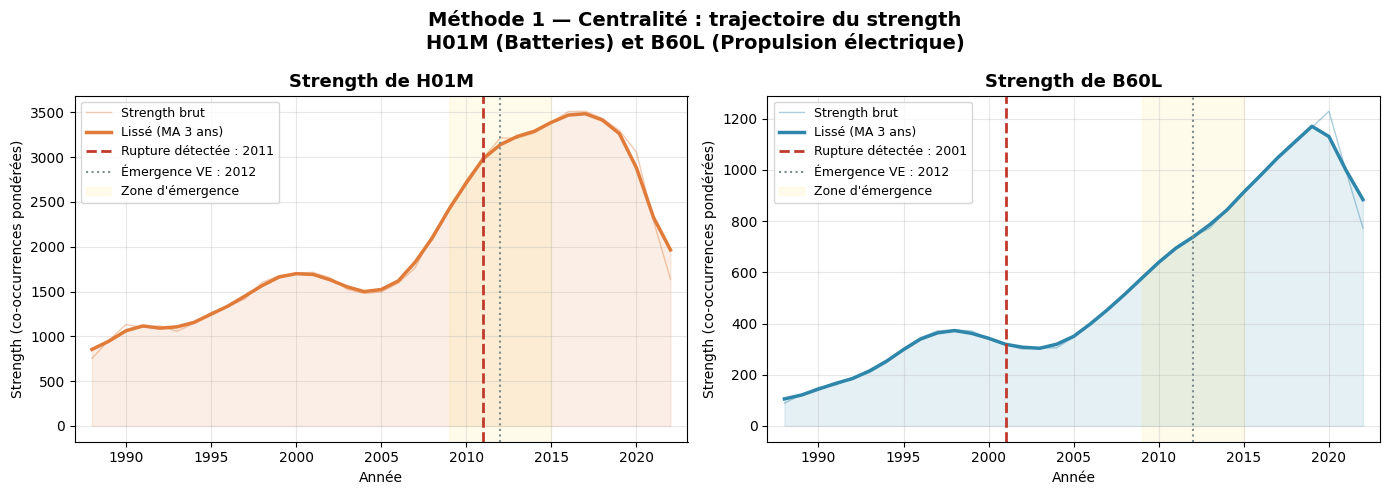

Lecture : le strength de H01M accélère nettement avant 2012,
signalant que les batteries deviennent un nœud structurant
du réseau technologique avant même que la convergence VE soit visible.


In [4]:
# ── Graphique 1 : Trajectoires du strength ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x, y, ys, t_break, cpc, color in [
    (axes[0], xi, yi, yi_s, t_break_i, CPC_I, C_H01M),
    (axes[1], xj, yj, yj_s, t_break_j, CPC_J, C_B60L)
]:
    ax.fill_between(x, 0, ys, alpha=0.12, color=color)
    ax.plot(x, y,  color=color, lw=1,   alpha=0.4, label='Strength brut')
    ax.plot(x, ys, color=color, lw=2.5, label=f'Lissé (MA {SMOOTH_W} ans)')
    ax.axvline(t_break,     color=C_RUPTURE, ls='--', lw=2,
               label=f'Rupture détectée : {t_break}')
    ax.axvline(YEAR_EMERGE, color=C_ATTENDU, ls=':',  lw=1.5,
               label=f'Émergence VE : {YEAR_EMERGE}')
    ax.axvspan(YEAR_EMERGE-3, YEAR_EMERGE+3, alpha=0.08,
               color='gold', label='Zone d\'émergence')
    ax.set_title(f'Strength de {cpc}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Année')
    ax.set_ylabel('Strength (co-occurrences pondérées)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(YEAR_START-1, YEAR_END+1)

plt.suptitle('Méthode 1 — Centralité : trajectoire du strength\n'
             'H01M (Batteries) et B60L (Propulsion électrique)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('M1_strength_trajectoires.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lecture : le strength de H01M accélère nettement avant 2012,')
print('signalant que les batteries deviennent un nœud structurant')
print('du réseau technologique avant même que la convergence VE soit visible.')

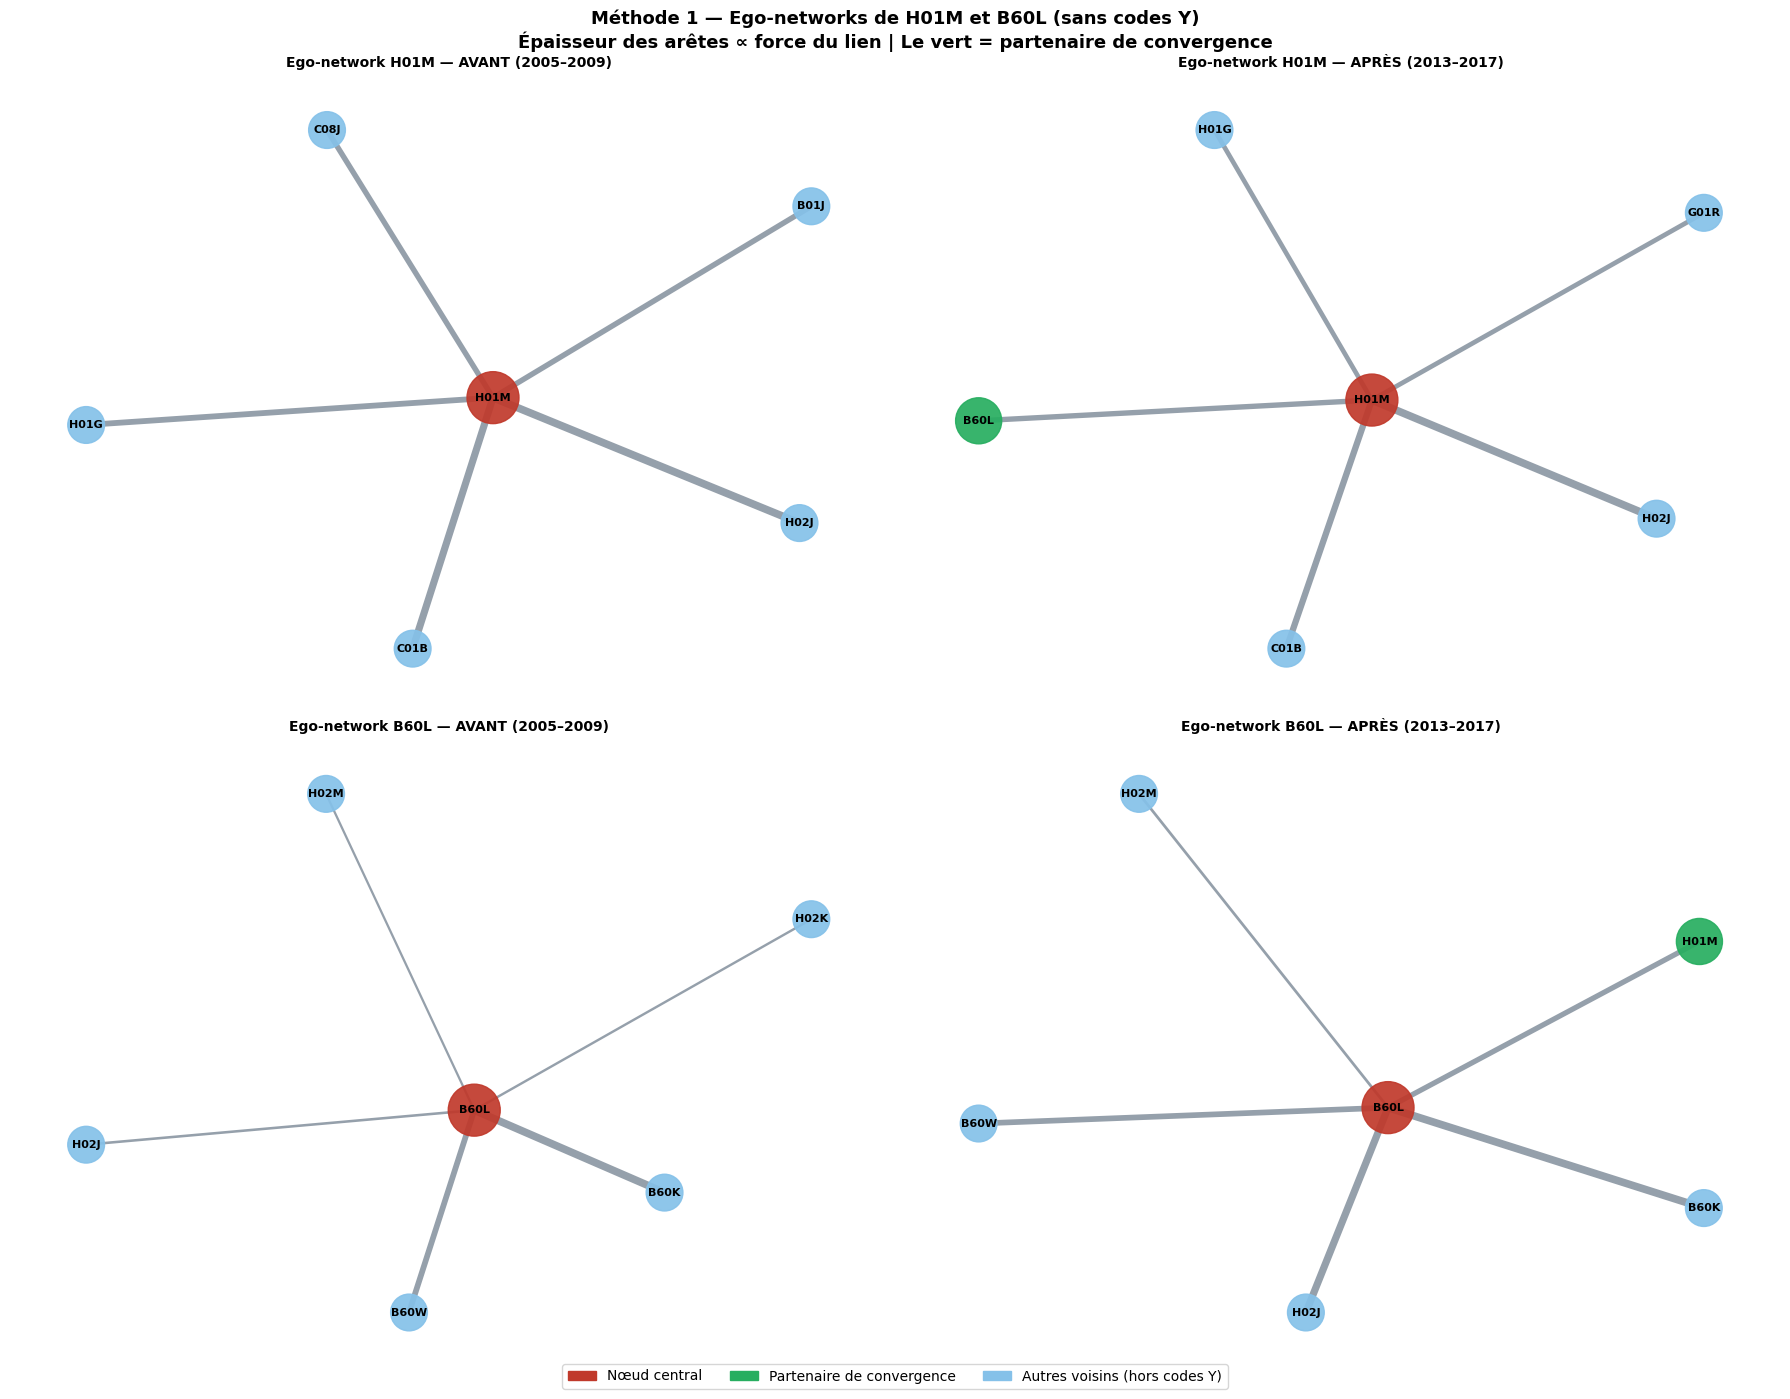

In [23]:
# ── Ego-networks sans codes Y ─────────────────────────────────
def build_ego_network_noY(df, cpc, year_start, year_end,
                           n_neighbors=N_NEIGHBORS):
    """
    Ego-network d'un code CPC, avec exclusion des codes Y.

    Les codes Y (Y02T, Y02E, etc.) sont des codes transversaux
    créés par l'EPO pour les technologies durables. Ils ne représentent
    pas un domaine distinct mais une étiquette thématique — leur présence
    dans le voisinage d'un code ne reflète pas une vraie convergence
    inter-domaines (remarque A. Bergeaud).

    On les exclut AVANT de sélectionner les N_NEIGHBORS plus proches,
    pour que les vrais partenaires technologiques apparaissent.
    """
    df_w = df[(df['year']>=year_start) & (df['year']<=year_end)]
    df_w = df_w[df_w['cpc4'].apply(lambda x: cpc in x)]

    weights = defaultdict(float)
    for _, row in df_w.iterrows():
        codes = row['cpc4']
        m = len(codes)
        if m < 2: continue
        yr = row['year']
        w  = (2.0/(m*(m-1))) * (N_mean/brevet_by_year.get(yr, N_mean))
        for c in codes:
            if c != cpc and not c.startswith('Y'):  # exclusion codes Y
                weights[c] += w

    top = sorted(weights.items(), key=lambda x: -x[1])[:n_neighbors]
    G = nx.Graph()
    G.add_node(cpc)
    for neighbor, w in top:
        G.add_edge(cpc, neighbor, weight=w)
    return G


def plot_ego_network_v2(G, cpc, title, ax, other_cpc=None):
    """
    Visualise un ego-network.
    L'épaisseur des arêtes est proportionnelle au poids (strength),
    conformément à la remarque d'A. Bergeaud.
    """
    pos = nx.spring_layout(G, seed=42, weight='weight', k=1.8)
    weights = [G[u][v]['weight'] for u,v in G.edges()]
    max_w   = max(weights) if weights else 1

    node_colors, node_sizes = [], []
    for n in G.nodes():
        if n == cpc:
            node_colors.append(C_RUPTURE); node_sizes.append(1400)
        elif n == other_cpc:
            node_colors.append('#27AE60'); node_sizes.append(1100)
        else:
            node_colors.append('#85C1E9'); node_sizes.append(700)

    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors, node_size=node_sizes,
                           alpha=0.92)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
    # Épaisseur proportionnelle au poids — plus le lien est fort, plus
    # l'arête est épaisse. Minimum de 0.5 pour que les liens faibles
    # restent visibles.
    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=[0.5 + 5*w/max_w for w in weights],
                           alpha=0.65, edge_color='#5D6D7E')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')


# Ego-networks pour H01M et B60L, avant et après
windows = {
    'avant'  : (2005, 2009),
    'après'  : (2013, 2017)
}
ego_graphs = {}
for cpc in [CPC_I, CPC_J]:
    ego_graphs[cpc] = {}
    for label, (y0, y1) in windows.items():
        ego_graphs[cpc][label] = build_ego_network_noY(df_raw, cpc, y0, y1)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

configs = [
    (CPC_I, 'avant', CPC_J, f'Ego-network {CPC_I} — AVANT (2005–2009)', axes[0,0]),
    (CPC_I, 'après', CPC_J, f'Ego-network {CPC_I} — APRÈS (2013–2017)', axes[0,1]),
    (CPC_J, 'avant', CPC_I, f'Ego-network {CPC_J} — AVANT (2005–2009)', axes[1,0]),
    (CPC_J, 'après', CPC_I, f'Ego-network {CPC_J} — APRÈS (2013–2017)', axes[1,1]),
]
for cpc, period, other, title, ax in configs:
    plot_ego_network_v2(ego_graphs[cpc][period], cpc, title, ax, other_cpc=other)

leg = [
    mpatches.Patch(color=C_RUPTURE,  label='Nœud central'),
    mpatches.Patch(color='#27AE60',  label='Partenaire de convergence'),
    mpatches.Patch(color='#85C1E9',  label='Autres voisins (hors codes Y)'),
]
fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
plt.suptitle('Méthode 1 — Ego-networks de H01M et B60L (sans codes Y)\n'
             'Épaisseur des arêtes ∝ force du lien | Le vert = partenaire de convergence',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('M1_ego_networks.png', dpi=150, bbox_inches='tight')
plt.show()

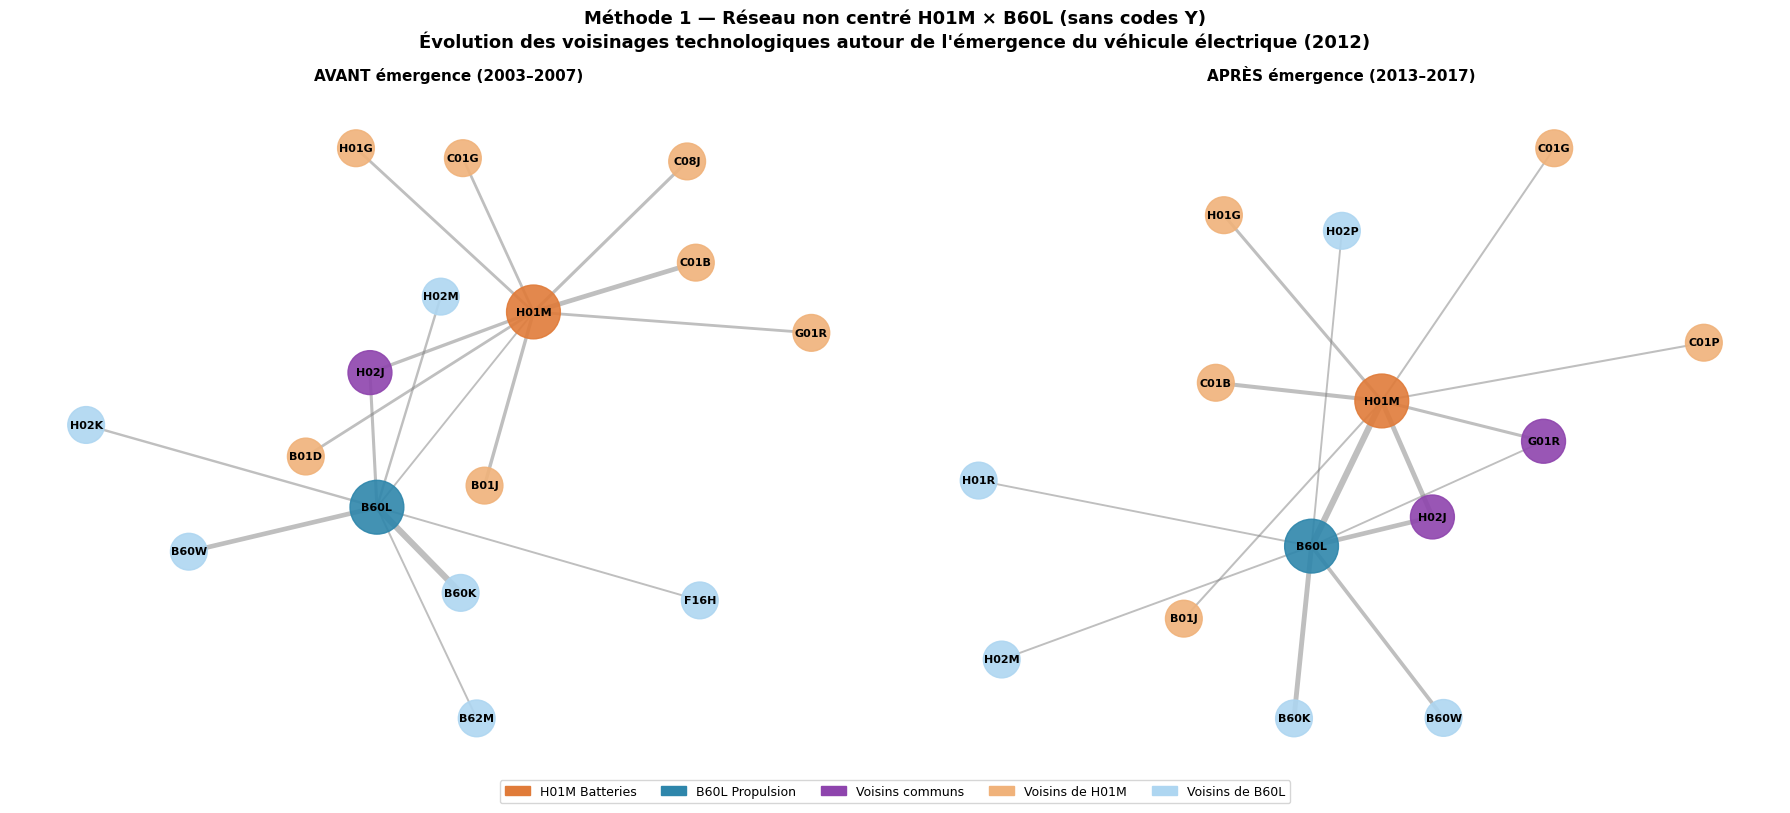

Voisins communs (hors Y) avant : 1 | après : 2
Nouveaux voisins communs : {'G01R'}


In [27]:
# ── Réseau non centré H01M × B60L sans codes Y ────────────────
def build_bipartite_noY(df, ci, cj, y0, y1, n=8):
    """
    Construit un réseau non centré montrant les voisins de ci et cj
    et leurs interconnexions, en excluant les codes Y.
    Inspiré de l'Annexe 7 de la note d'étape 2.
    """
    Gi = build_ego_network_noY(df, ci, y0, y1, n)
    Gj = build_ego_network_noY(df, cj, y0, y1, n)
    G  = nx.Graph()
    for u, v, d in list(Gi.edges(data=True)) + list(Gj.edges(data=True)):
        if G.has_edge(u,v): G[u][v]['weight'] += d['weight']
        else: G.add_edge(u, v, weight=d['weight'])
    ni = set(Gi.nodes()) - {ci}
    nj = set(Gj.nodes()) - {cj}
    return G, ni, nj, ni & nj


def plot_bipartite_noY(G, ni, nj, common, ci, cj, title, ax):
    pos = nx.spring_layout(G, seed=42, weight='weight', k=2)
    weights = [G[u][v].get('weight',1) for u,v in G.edges()]
    max_w   = max(weights) if weights else 1
    cmap = {ci: C_H01M, cj: C_B60L}
    color_map, size_map = [], []
    for n in G.nodes():
        if n in cmap:  color_map.append(cmap[n]); size_map.append(1500)
        elif n in common: color_map.append(C_COMMUN); size_map.append(1000)
        elif n in ni:  color_map.append('#F0B27A'); size_map.append(700)
        else:          color_map.append('#AED6F1'); size_map.append(700)
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=color_map, node_size=size_map, alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=[0.5+4*w/max_w for w in weights],
                           alpha=0.5, edge_color='gray')
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
G05,ni05,nj05,c05 = build_bipartite_noY(df_raw,CPC_I,CPC_J,2003,2007)
G15,ni15,nj15,c15 = build_bipartite_noY(df_raw,CPC_I,CPC_J,2013,2017)
plot_bipartite_noY(G05,ni05,nj05,c05,CPC_I,CPC_J,'AVANT émergence (2003–2007)',axes[0])
plot_bipartite_noY(G15,ni15,nj15,c15,CPC_I,CPC_J,'APRÈS émergence (2013–2017)',axes[1])

leg = [
    mpatches.Patch(color=C_H01M,   label=f'{CPC_I} Batteries'),
    mpatches.Patch(color=C_B60L,   label=f'{CPC_J} Propulsion'),
    mpatches.Patch(color=C_COMMUN, label='Voisins communs'),
    mpatches.Patch(color='#F0B27A', label=f'Voisins de {CPC_I}'),
    mpatches.Patch(color='#AED6F1', label=f'Voisins de {CPC_J}'),
]
fig.legend(handles=leg, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Méthode 1 — Réseau non centré H01M × B60L (sans codes Y)\n'
             'Évolution des voisinages technologiques autour de l\'émergence du véhicule électrique (2012)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('M1_reseau_non_centre.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Voisins communs (hors Y) avant : {len(c05)} | après : {len(c15)}')
print(f'Nouveaux voisins communs : {c15 - c05}')

---
# MÉTHODE 2 — Clustering dynamique

## Qu'est-ce qu'un cluster absorbant ?

On partitionne les codes CPC en K=10 groupes (clusters) par k-means
appliqué à la matrice de co-occurrence réduite par ACP.
Cette partition est recalculée chaque année.

Un cluster est dit **absorbant** s'il satisfait deux critères :
- **Entropie d'entrée élevée** : il attire des codes venant de beaucoup
  de clusters différents → il est un pôle de convergence multilatérale
- **Persistance élevée** : les codes qui y entrent y restent → c'est
  une recomposition durable, pas transitoire

## Ce qu'on cherche ici

On veut répondre à trois questions :
1. H01M et B60L étaient-ils dans le même cluster **avant** 2012 ?
2. Y sont-ils ensemble **autour** de 2012 ?
3. Si oui, ce cluster était-il absorbant ? Qui d'autre s'y trouvait ?

L'objectif n'est pas de **dater** la convergence par le clustering
(on a vu que ça génère des artefacts en début de période),
mais de **caractériser** la structure communautaire autour de l'émergence.

## Stabilisation des labels par matching hongrois

Le k-means est non-déterministe dans ses labels : le cluster '3' en 1990
n'a rien à voir avec le cluster '3' en 2010. Pour suivre les clusters
dans le temps, on aligne les labels entre périodes consécutives par
l'algorithme hongrois (linear_sum_assignment), qui trouve la permutation
de labels maximisant le chevauchement entre t et t+1.

In [30]:
def build_cooc_window(df, t, window=WINDOW):
    df_w = df[(df['year']>=t-window//2) & (df['year']<=t+window//2)]
    counter = Counter()
    for codes in df_w['cpc4']:
        for ci,cj in itertools.combinations(sorted(set(codes)),2):
            counter[(ci,cj)] += 1; counter[(cj,ci)] += 1
    cooc = pd.DataFrame([(i,j,c) for (i,j),c in counter.items()],
                        columns=['cpc_i','cpc_j','count'])
    if len(cooc) == 0: return pd.DataFrame()
    rs = cooc.groupby('cpc_i')['count'].sum().rename('row_sum')
    cooc = cooc.join(rs, on='cpc_i')
    cooc['M_ij'] = cooc['count'] / cooc['row_sum']
    return cooc


def align_labels(labels_prev, labels_curr, k):
    """
    Réassigne les labels de labels_curr pour maximiser le chevauchement
    avec labels_prev (algorithme hongrois).

    Construit une matrice de confusion k×k, puis trouve la permutation
    qui maximise la trace (= chevauchement total entre les deux partitions).
    """
    confusion = np.zeros((k, k), dtype=int)
    for p, c in zip(labels_prev, labels_curr):
        if 0 <= p < k and 0 <= c < k:
            confusion[p, c] += 1
    row_ind, col_ind = linear_sum_assignment(-confusion)
    mapping = {col: row for row,col in zip(row_ind, col_ind)}
    return np.array([mapping.get(l, l) for l in labels_curr])


print('Clustering dynamique avec alignement des labels...')
pca_obj = PCA(n_components=N_PCA, random_state=0)
km_obj  = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)

cluster_records = []
prev_labels = None
prev_nodes  = None

for t in range(YEAR_START, YEAR_END+1):
    cooc = build_cooc_window(df_raw, t)
    if len(cooc) == 0: continue
    M = cooc.pivot(index='cpc_i', columns='cpc_j', values='M_ij').fillna(0)
    if M.shape[0] < N_PCA+1: continue

    labels_raw = km_obj.fit_predict(pca_obj.fit_transform(M))

    # Alignement avec la période précédente
    if prev_labels is not None and prev_nodes is not None:
        common_nodes = list(set(M.index) & set(prev_nodes))
        if len(common_nodes) > K_CLUSTERS:
            prev_l = np.array([prev_labels[list(prev_nodes).index(n)]
                               for n in common_nodes
                               if n in prev_nodes])
            curr_l = np.array([labels_raw[list(M.index).index(n)]
                               for n in common_nodes
                               if n in M.index])
            if len(prev_l) == len(curr_l) and len(prev_l) > 0:
                labels_raw = align_labels(prev_l, labels_raw, K_CLUSTERS)

    prev_labels = labels_raw
    prev_nodes  = list(M.index)

    for cpc, cl in zip(M.index, labels_raw):
        cluster_records.append({'year':t, 'cpc4':cpc, 'cluster':int(cl)})

cluster_df = pd.DataFrame(cluster_records)
print(f'  {cluster_df["year"].nunique()} années | {cluster_df["cpc4"].nunique()} codes')

Clustering dynamique avec alignement des labels...
  35 années | 673 codes


In [31]:
# ── Score d'absorption, H_in et persistance ───────────────────
cl_sorted = cluster_df.sort_values(['cpc4','year'])
transitions = []
for cpc, sub in cl_sorted.groupby('cpc4'):
    sub = sub.sort_values('year')
    for i in range(len(sub)-1):
        if sub.iloc[i+1]['year'] - sub.iloc[i]['year'] == 1:
            transitions.append({
                'cpc': cpc,
                'year_t'    : sub.iloc[i]['year'],
                'year_t1'   : sub.iloc[i+1]['year'],
                'cluster_t' : sub.iloc[i]['cluster'],
                'cluster_t1': sub.iloc[i+1]['cluster']
            })
trans_df = pd.DataFrame(transitions)

def entropy_fn(p):
    p = p[p>0]; return -np.sum(p*np.log(p))

inflow = (trans_df.groupby(['year_t1','cluster_t1'])['cluster_t']
          .value_counts(normalize=True).rename('p').reset_index())
H_in   = (inflow.groupby(['year_t1','cluster_t1'])['p']
          .apply(entropy_fn).reset_index(name='H_in'))
persist = (trans_df.groupby(['year_t','cluster_t'])
           .apply(lambda x: np.mean(x['cluster_t1']==x['cluster_t']))
           .reset_index(name='persistence'))
absorb = (H_in.merge(persist,
                     left_on=['year_t1','cluster_t1'],
                     right_on=['year_t','cluster_t'], how='left')
          .drop(columns=['year_t','cluster_t'])
          .rename(columns={'year_t1':'year','cluster_t1':'cluster'}))
absorb['absorption'] = absorb['H_in'] * absorb['persistence'].fillna(0)

# Trajectoire de H01M et B60L
cl_lkp = cluster_df.set_index(['cpc4','year'])['cluster'].to_dict()
traj = []
for t in range(YEAR_START, YEAR_END+1):
    ci = cl_lkp.get((CPC_I,t)); cj = cl_lkp.get((CPC_J,t))
    if ci is None or cj is None: continue
    abs_row = absorb[(absorb['year']==t) & (absorb['cluster']==ci)]
    traj.append({
        'year': t, 'cluster_H01M': ci, 'cluster_B60L': cj,
        'same': ci==cj,
        'H_in'       : abs_row['H_in'].values[0]        if len(abs_row)>0 else 0,
        'persistence': abs_row['persistence'].values[0]  if len(abs_row)>0 else 0,
        'absorption' : abs_row['absorption'].values[0]   if len(abs_row)>0 else 0,
    })
df_traj = pd.DataFrame(traj)

print('Tableau récapitulatif (années clés) :')
display(df_traj[df_traj['year'].isin([2005,2008,2010,2011,2012,2013,2015,2018])]
        [['year','cluster_H01M','cluster_B60L','same','H_in','persistence','absorption']])

Tableau récapitulatif (années clés) :


,year,cluster_H01M,cluster_B60L,same,H_in,persistence,absorption
17,2005,1,6,False,0.654670,0.000000,0.000000
20,2008,0,5,False,0.536665,0.000000,0.000000
22,2010,8,5,False,0.314492,0.047619,0.014976
23,2011,5,0,False,0.815921,0.960000,0.783284
24,2012,5,3,False,0.470900,0.000000,0.000000
25,2013,9,5,False,-0.000000,0.000000,-0.000000
27,2015,9,1,False,-0.000000,1.000000,-0.000000
30,2018,1,9,False,-0.000000,0.000000,-0.000000


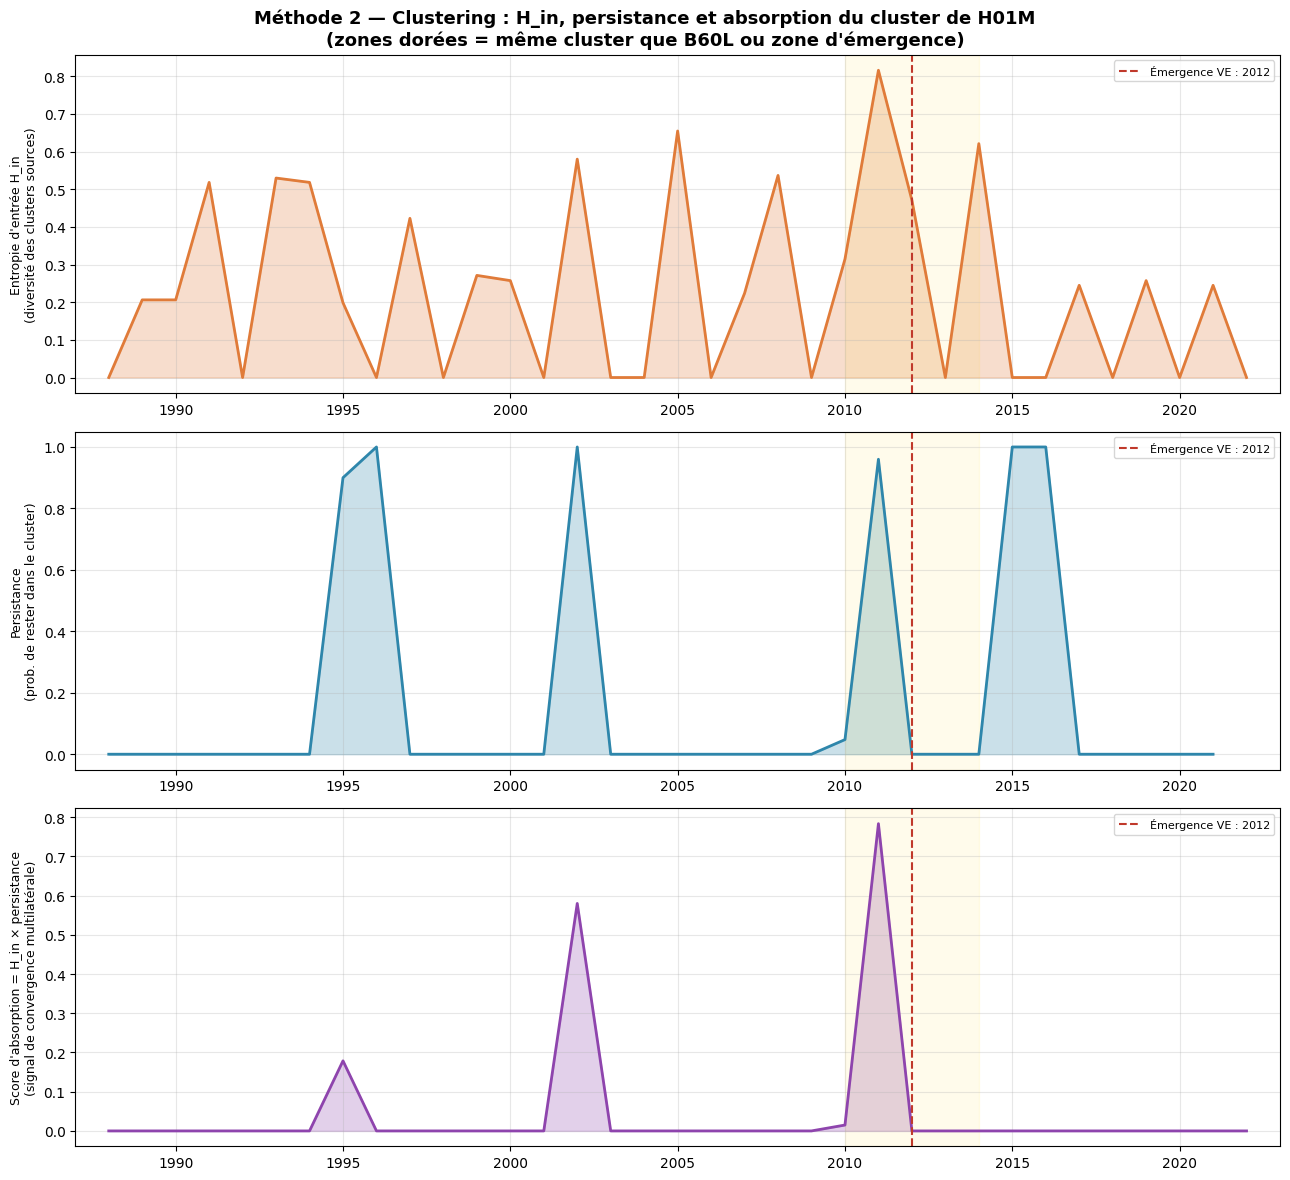

In [32]:
# ── Graphique 2 : H_in, persistance et absorption séparément ──
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

for ax, col, label, color in [
    (axes[0], 'H_in',        'Entropie d\'entrée H_in\n(diversité des clusters sources)',       C_H01M),
    (axes[1], 'persistence', 'Persistance\n(prob. de rester dans le cluster)',                  C_B60L),
    (axes[2], 'absorption',  'Score d\'absorption = H_in × persistance\n(signal de convergence multilatérale)', C_COMMUN)
]:
    ax.fill_between(df_traj['year'], 0, df_traj[col], alpha=0.25, color=color)
    ax.plot(df_traj['year'], df_traj[col], color=color, lw=2)
    ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5,
               label=f'Émergence VE : {YEAR_EMERGE}')
    ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.08, color='gold')
    # Zones de même cluster
    for yr in df_traj[df_traj['same']]['year']:
        ax.axvspan(yr-0.5, yr+0.5, alpha=0.15, color='gold')
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlim(YEAR_START-1, YEAR_END+1)

plt.suptitle('Méthode 2 — Clustering : H_in, persistance et absorption du cluster de H01M\n'
             '(zones dorées = même cluster que B60L ou zone d\'émergence)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('M2_absorption_detail.png', dpi=150, bbox_inches='tight')
plt.show()

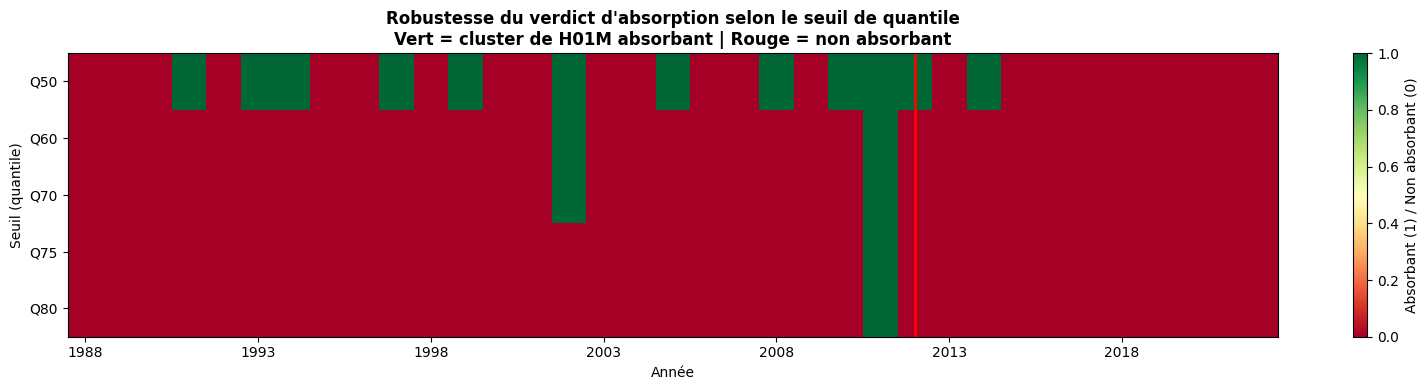

In [33]:
# ── Graphique 3 : Robustesse des seuils d'absorption ──────────
# On teste si le verdict change selon le seuil choisi.
# Si H01M est absorbant à tous les seuils, le résultat est robuste.
quantiles = [0.50, 0.60, 0.70, 0.75, 0.80]
robustness = []

for q in quantiles:
    H_thresh = absorb['H_in'].quantile(q)
    P_thresh = absorb['persistence'].quantile(q)
    absorb_q = absorb.copy()
    absorb_q['is_abs'] = (
        (absorb_q['H_in'] >= H_thresh) &
        (absorb_q['persistence'] >= P_thresh)
    )
    # Années où H01M est absorbant
    for _, row in df_traj.iterrows():
        a = absorb_q[(absorb_q['year']==row['year']) &
                     (absorb_q['cluster']==row['cluster_H01M'])]
        is_abs = a['is_abs'].values[0] if len(a)>0 else False
        robustness.append({'quantile': q, 'year': row['year'],
                           'is_absorbing': is_abs})

df_rob = pd.DataFrame(robustness)

# Heatmap robustesse
pivot_rob = df_rob.pivot(index='quantile', columns='year', values='is_absorbing')
fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot_rob.values.astype(float),
               aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_yticks(range(len(quantiles)))
ax.set_yticklabels([f'Q{int(q*100)}' for q in quantiles])
years_shown = list(range(YEAR_START, YEAR_END+1, 5))
ax.set_xticks([list(pivot_rob.columns).index(y)
               for y in years_shown if y in pivot_rob.columns])
ax.set_xticklabels(years_shown)
ax.axvline(list(pivot_rob.columns).index(YEAR_EMERGE)
           if YEAR_EMERGE in pivot_rob.columns else 0,
           color='red', lw=2, label=f'Émergence {YEAR_EMERGE}')
plt.colorbar(im, ax=ax, label='Absorbant (1) / Non absorbant (0)')
ax.set_title('Robustesse du verdict d\'absorption selon le seuil de quantile\n'
             'Vert = cluster de H01M absorbant | Rouge = non absorbant',
             fontweight='bold')
ax.set_xlabel('Année'); ax.set_ylabel('Seuil (quantile)')
plt.tight_layout()
plt.savefig('M2_robustesse_seuils.png', dpi=150, bbox_inches='tight')
plt.show()

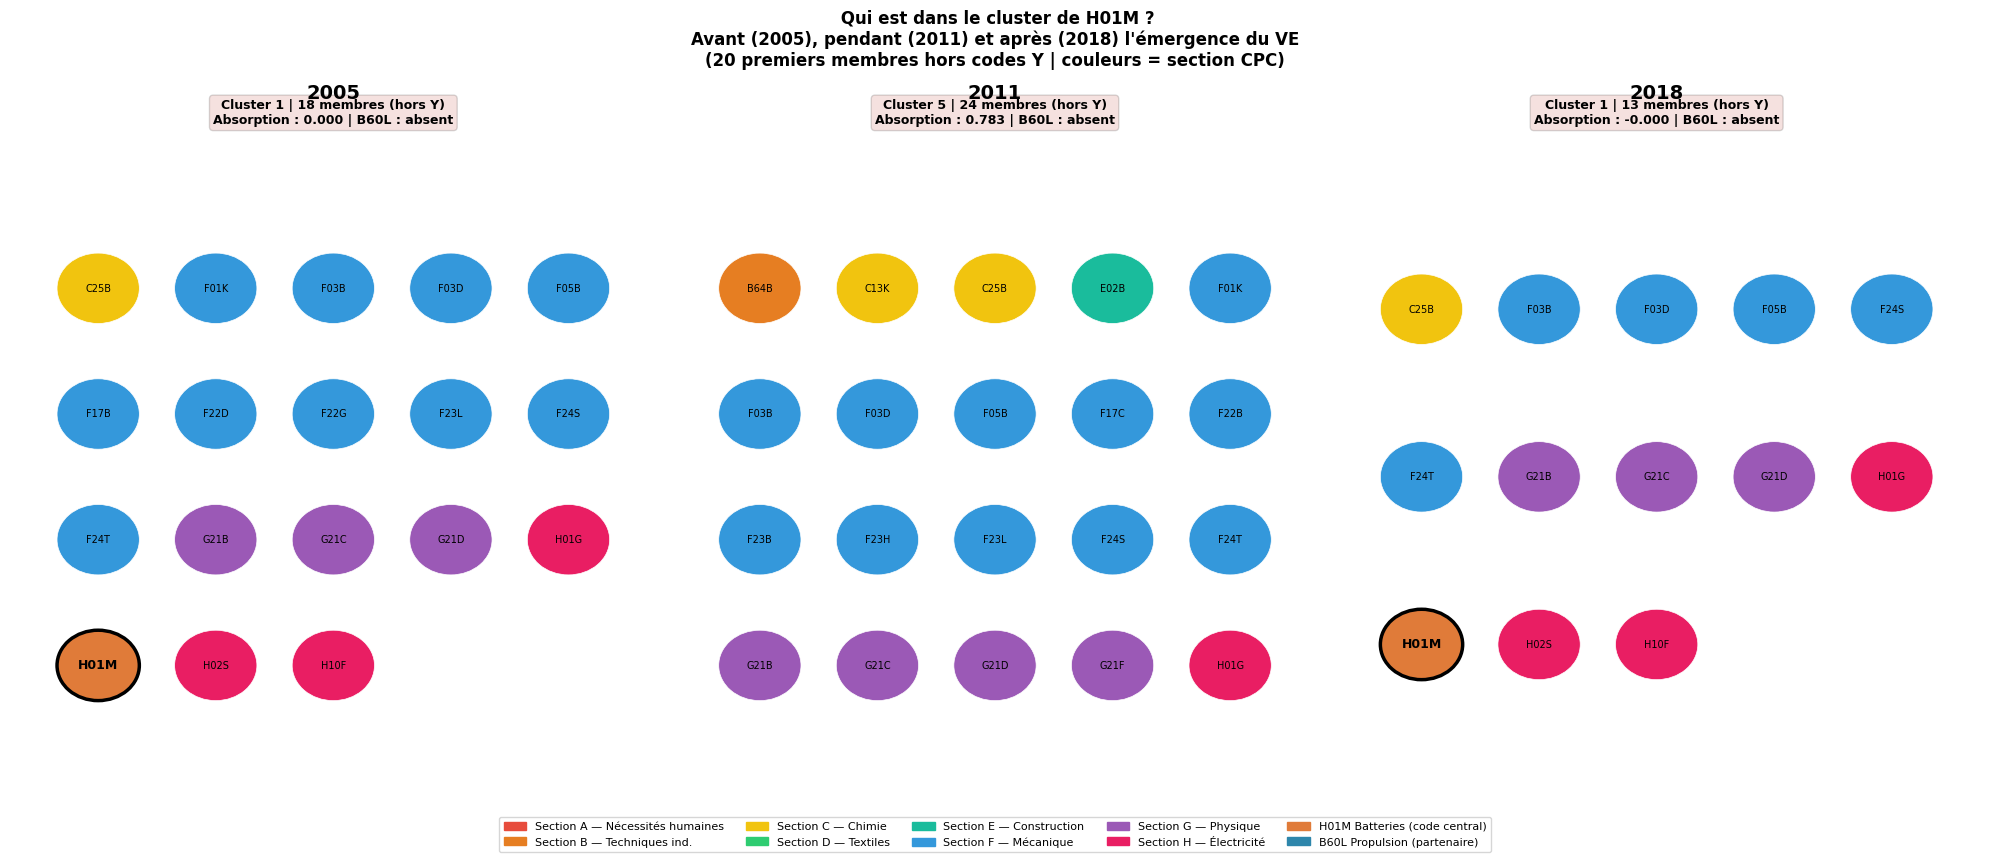

In [36]:
# ── Graphique : composition visuelle des clusters ─────────────
# Chaque membre du cluster est affiché comme une bulle colorée
# selon sa section CPC (première lettre du code).
# H01M et B60L sont mis en évidence avec un contour noir.

section_colors = {
    'A': '#E74C3C',  # Nécessités humaines (médical, agriculture)
    'B': '#E67E22',  # Techniques industrielles (séparation, mélange)
    'C': '#F1C40F',  # Chimie, métallurgie
    'D': '#2ECC71',  # Textiles, papier
    'E': '#1ABC9C',  # Construction, mines
    'F': '#3498DB',  # Mécanique, éclairage, chauffage
    'G': '#9B59B6',  # Physique, instruments
    'H': '#E91E63',  # Électricité, électronique
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, yr in zip(axes, MOMENTS_CLES):
    cl_i, abs_i, members_i = get_cluster_composition(yr, CPC_I)
    if cl_i is None:
        ax.text(0.5, 0.5, 'N/D', ha='center', transform=ax.transAxes)
        continue

    b60l_in = CPC_J in cluster_df[
        (cluster_df['year'] == yr) &
        (cluster_df['cluster'] == cl_i)
    ]['cpc4'].tolist()

    # Affichage en grille — 5 colonnes max
    members_show = members_i[:20]
    n    = len(members_show)
    cols = 5
    rows = (n + cols - 1) // cols

    for idx, code in enumerate(members_show):
        col_i = idx % cols
        row_i = idx // cols
        x_pos = (col_i + 0.5) / cols
        y_pos = 1 - (row_i + 0.5) / max(rows, 1)

        section = code[0] if code else 'X'
        color   = section_colors.get(section, '#95A5A6')

        if code == CPC_I:
            color = C_H01M; fs = 9; fw = 'bold'
            ec = 'black';   lw = 2.5
        elif code == CPC_J:
            color = C_B60L; fs = 9; fw = 'bold'
            ec = 'black';   lw = 2.5
        else:
            fs = 7; fw = 'normal'
            ec = 'white'; lw = 0.5

        circle = plt.Circle(
            (x_pos, y_pos), 0.07,
            color=color, ec=ec, lw=lw, zorder=2
        )
        ax.add_patch(circle)
        ax.text(x_pos, y_pos, code,
                ha='center', va='center',
                fontsize=fs, fontweight=fw, zorder=3)

    # Bandeau d'information en haut du panneau
    status_color = '#27AE60' if b60l_in else '#C0392B'
    ax.text(0.5, 1.08,
            f'Cluster {cl_i} | {len(members_i)} membres (hors Y)\n'
            f'Absorption : {abs_i:.3f} | '
            f'{CPC_J} : {"présent" if b60l_in else "absent"}',
            ha='center', va='bottom',
            transform=ax.transAxes,
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round',
                      facecolor=status_color, alpha=0.15))

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.1, 1.1)
    ax.set_title(f'{yr}', fontsize=14,
                 fontweight='bold', pad=55)
    ax.axis('off')

# Légende des sections CPC
legend_patches = [
    mpatches.Patch(color=c, label=f'Section {s} — '
                   + {'A':'Nécessités humaines',
                      'B':'Techniques ind.',
                      'C':'Chimie',
                      'D':'Textiles',
                      'E':'Construction',
                      'F':'Mécanique',
                      'G':'Physique',
                      'H':'Électricité'}.get(s,''))
    for s, c in section_colors.items()
]
legend_patches += [
    mpatches.Patch(color=C_H01M,
                   label=f'{CPC_I} Batteries (code central)'),
    mpatches.Patch(color=C_B60L,
                   label=f'{CPC_J} Propulsion (partenaire)'),
]
fig.legend(handles=legend_patches,
           loc='lower center', ncol=5,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))

plt.suptitle(
    f' Qui est dans le cluster de {CPC_I} ?\n'
    f'Avant (2005), pendant (2011) et après (2018) l\'émergence du VE\n'
    f'(20 premiers membres hors codes Y | couleurs = section CPC)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('M2_composition_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

Distance directe H01M ↔ B60L (années clés) :


,year,dist_direct
17,2005,0.4062
20,2008,0.4232
22,2010,0.4286
23,2011,0.4176
24,2012,0.4023
25,2013,0.3852
27,2015,0.3445
30,2018,0.3116
34,2022,0.2758


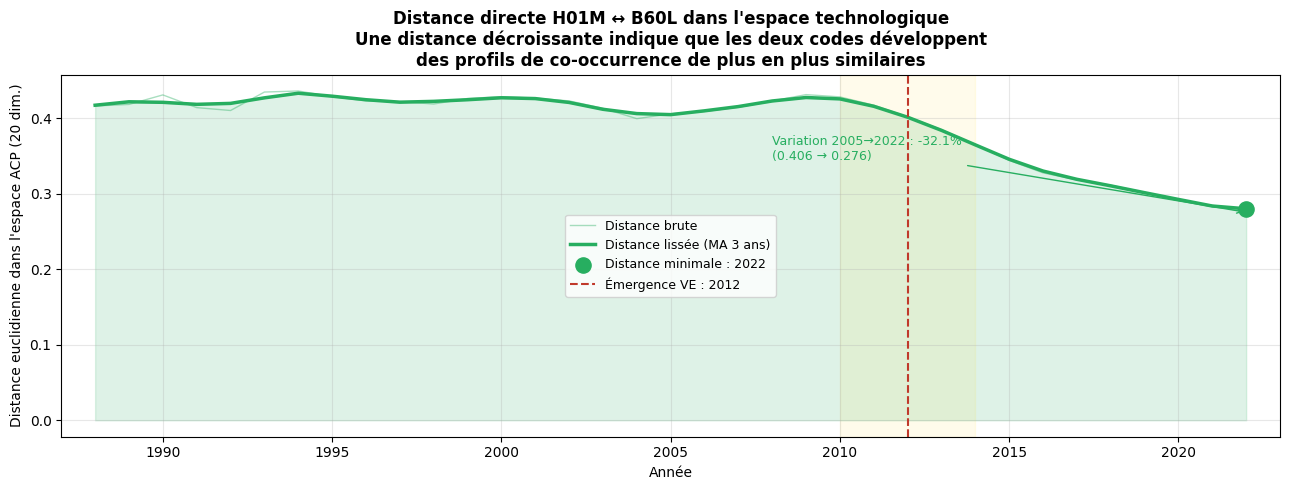


Distance 2005 : 0.4062
Distance 2022 : 0.2758
Variation     : -32.1%
Distance minimale en : 2022


In [40]:
# ── Distance directe H01M × B60L dans l'espace ACP ────────────
#
# Pour chaque année t :
# 1. On construit la matrice de co-occurrence M (codes × codes)
# 2. On projette par ACP en 20 dimensions
# 3. On extrait les vecteurs de H01M et B60L dans cet espace
# 4. On calcule la distance euclidienne entre ces deux vecteurs
#
# Une distance décroissante = les deux codes développent des
# profils de co-occurrence de plus en plus similaires.
# C'est une mesure de convergence structurelle, complémentaire
# au Jaccard qui mesure la co-occurrence directe.

pca_dist = PCA(n_components=N_PCA, random_state=0)

dist_records = []

for t in range(YEAR_START, YEAR_END+1):
    cooc = build_cooc_window(df_raw, t)
    if len(cooc) == 0: continue
    M = cooc.pivot(index='cpc_i', columns='cpc_j',
                   values='M_ij').fillna(0)
    if M.shape[0] < N_PCA+1: continue
    if CPC_I not in M.index or CPC_J not in M.index: continue

    # Projection ACP
    M_pca = pca_dist.fit_transform(M)

    # Vecteurs de H01M et B60L dans l'espace réduit
    idx_i = list(M.index).index(CPC_I)
    idx_j = list(M.index).index(CPC_J)
    vec_i = M_pca[idx_i]
    vec_j = M_pca[idx_j]

    # Distance euclidienne directe
    dist = np.linalg.norm(vec_i - vec_j)

    dist_records.append({'year': t, 'dist_direct': dist})

df_dist = pd.DataFrame(dist_records)

# Tableau des valeurs aux années clés
print('Distance directe H01M ↔ B60L (années clés) :')
display(df_dist[
    df_dist['year'].isin([2005,2008,2010,2011,2012,2013,2015,2018,2022])
].round(4))

# ── Graphique ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

y  = df_dist['dist_direct'].values
ys = smooth(y)

ax.fill_between(df_dist['year'], 0, ys, alpha=0.15, color='#27AE60')
ax.plot(df_dist['year'], y,  color='#27AE60', lw=1, alpha=0.4,
        label='Distance brute')
ax.plot(df_dist['year'], ys, color='#27AE60', lw=2.5,
        label=f'Distance lissée (MA {SMOOTH_W} ans)')

# Annoter le minimum
idx_min = np.nanargmin(ys)
yr_min  = df_dist['year'].values[idx_min]
ax.scatter([yr_min], [ys[idx_min]], color='#27AE60', s=120, zorder=5,
           label=f'Distance minimale : {yr_min}')

# Ligne d'émergence et zone
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5,
           label=f'Émergence VE : {YEAR_EMERGE}')
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.08, color='gold')

# Annoter la variation
dist_2005 = df_dist[df_dist['year']==2005]['dist_direct'].values[0]
dist_2022 = df_dist[df_dist['year']==2022]['dist_direct'].values[0]
variation = (dist_2022 - dist_2005) / dist_2005 * 100
ax.annotate(
    f'Variation 2005→2022 : {variation:+.1f}%\n'
    f'({dist_2005:.3f} → {dist_2022:.3f})',
    xy=(2022, dist_2022),
    xytext=(2008, dist_2005 * 0.85),
    fontsize=9, color='#27AE60',
    arrowprops=dict(arrowstyle='->', color='#27AE60')
)

ax.set_xlabel('Année')
ax.set_ylabel('Distance euclidienne dans l\'espace ACP (20 dim.)')
ax.set_title(
    'Distance directe H01M ↔ B60L dans l\'espace technologique\n'
    'Une distance décroissante indique que les deux codes développent\n'
    'des profils de co-occurrence de plus en plus similaires',
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(YEAR_START-1, YEAR_END+1)

plt.tight_layout()
plt.savefig('M2_distance_directe.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDistance 2005 : {dist_2005:.4f}')
print(f'Distance 2022 : {dist_2022:.4f}')
print(f'Variation     : {variation:+.1f}%')
print(f'Distance minimale en : {yr_min}')

Calcul de la distance directe dans l'espace ACP
Pour mesurer si H01M et B60L se rapprochent structurellement dans le temps — même sans appartenir au même cluster — on calcule leur distance directe dans l'espace technologique réduit.
La procédure est la suivante. Pour chaque fenêtre temporelle t, on construit la matrice de co-occurrence M où chaque ligne représente un code CPC et chaque colonne sa relation normalisée avec tous les autres codes. Chaque code i est ainsi décrit par un vecteur de ~600 dimensions — sa "signature" de co-occurrence avec l'ensemble de l'espace technologique.
On réduit ensuite cette matrice à 20 dimensions par Analyse en Composantes Principales (ACP). Ces 20 composantes capturent l'essentiel de la structure de proximité entre codes tout en éliminant le bruit des dimensions marginales.
Dans cet espace réduit, chaque code est un point. La distance directe entre H01M et B60L est simplement la distance euclidienne entre ces deux points :
d(H01M,B60L,t)=∥vH01M​(t)−vB60L​(t)∥2​
Une distance décroissante signifie que les deux codes développent des profils de co-occurrence de plus en plus similaires — ils fréquentent les mêmes partenaires technologiques de façon croissante. C'est une mesure de convergence structurelle dans l'espace des brevets, complémentaire au Jaccard qui mesure la co-occurrence directe.

---
# MÉTHODE 3 — Séries temporelles

## Approche

La convergence technologique peut se manifester par une **synchronisation
des cycles d'innovation** : quand l'un des domaines innove, l'autre aussi.
Nous explorons cette dimension avec plusieurs outils de séries temporelles.

## Les séries utilisées

Nous travaillons sur deux types de séries :
1. **Séries de co-occurrences directes** : nombre annuel de brevets
   contenant simultanément H01M et B60L. Mesure le lien direct.
2. **Séries d'activité globale** : somme pondérée des co-occurrences
   de chaque code avec tous ses partenaires. Mesure l'activité totale.

## Plan d'analyse

1. Test de stationnarité (ADF) — les séries sont-elles stationnaires ?
2. Différenciation si nécessaire — pour éviter les corrélations spurieuses
3. Corrélation glissante — synchronisation des cycles
4. Corrélation croisée avec lags — H01M précède-t-il B60L ?
5. Test de cointégration — relation de long terme ?
6. Causalité de Granger — quelle est la direction causale ?

In [43]:
# ── Séries de co-occurrences directes H01M×B60L ───────────────
# Comptage brut annuel des brevets contenant chaque code.
# Plus direct et plus interprétable que l'activité pondérée.

cooc_direct = []
for t in range(YEAR_START, YEAR_END+1):
    n_i = n_j = n_ij = 0
    for codes in df_raw[df_raw['year']==t]['cpc4']:
        hi = CPC_I in codes; hj = CPC_J in codes
        if hi: n_i  += 1
        if hj: n_j  += 1
        if hi and hj: n_ij += 1
    cooc_direct.append({'year':t, 'n_H01M':n_i,
                        'n_B60L':n_j, 'n_both':n_ij})

df_cooc     = pd.DataFrame(cooc_direct)
serie_H01M  = df_cooc.set_index('year')['n_H01M']
serie_B60L  = df_cooc.set_index('year')['n_B60L']
serie_both  = df_cooc.set_index('year')['n_both']

# ── Tests de stationnarité (ADF) ──────────────────────────────
# H0 : la série a une racine unitaire (non-stationnaire)
# Si p > 0.05 : on ne rejette pas H0 → série non-stationnaire

# Différences premières et secondes
dH01M  = serie_H01M.diff().dropna()
dB60L  = serie_B60L.diff().dropna()
d2H01M = serie_H01M.diff().diff().dropna()
d2B60L = serie_B60L.diff().diff().dropna()

print('═'*65)
print('TEST DE STATIONNARITÉ (Augmented Dickey-Fuller)')
print('H0 : la série est non-stationnaire (racine unitaire)')
print('Seuil : p < 0.05 → stationnaire')
print('═'*65)

series_to_test = [
    ('H01M (niveaux)',  serie_H01M),
    ('B60L (niveaux)',  serie_B60L),
    ('H01M (diff.1)',   dH01M),
    ('B60L (diff.1)',   dB60L),
    ('H01M (diff.2)',   d2H01M),
    ('B60L (diff.2)',   d2B60L),
]

adf_results = {}
for name, serie in series_to_test:
    stat, pval, _, _, _, _ = adfuller(serie, autolag='AIC')
    if pval < 0.05:
        verdict = '✅ Stationnaire'
    else:
        verdict = '❌ Non-stationnaire → différencier'
    adf_results[name] = {'ADF': stat, 'p-value': pval,
                         'Verdict': verdict}
    print(f'  {name:25s} : ADF={stat:7.3f} | p={pval:.4f} | {verdict}')

print('\nConclusion :')
print('  H01M ~ I(1) : stationnaire en différence première')
print('  B60L ~ I(2) : stationnaire en différence seconde')
print('  → Ordres d\'intégration différents')
print('  → On travaille sur d²H01M et d²B60L pour Granger')
print('  → Le test de cointégration standard n\'est pas applicable')
print('    (suppose I(1) pour les deux séries)')

═════════════════════════════════════════════════════════════════
TEST DE STATIONNARITÉ (Augmented Dickey-Fuller)
H0 : la série est non-stationnaire (racine unitaire)
Seuil : p < 0.05 → stationnaire
═════════════════════════════════════════════════════════════════
  H01M (niveaux)            : ADF=  0.603 | p=0.9877 | ❌ Non-stationnaire → différencier
  B60L (niveaux)            : ADF=  2.751 | p=1.0000 | ❌ Non-stationnaire → différencier
  H01M (diff.1)             : ADF= -5.224 | p=0.0000 | ✅ Stationnaire
  B60L (diff.1)             : ADF= -2.523 | p=0.1099 | ❌ Non-stationnaire → différencier
  H01M (diff.2)             : ADF= -3.498 | p=0.0080 | ✅ Stationnaire
  B60L (diff.2)             : ADF= -7.411 | p=0.0000 | ✅ Stationnaire

Conclusion :
  H01M ~ I(1) : stationnaire en différence première
  B60L ~ I(2) : stationnaire en différence seconde
  → Ordres d'intégration différents
  → On travaille sur d²H01M et d²B60L pour Granger
  → Le test de cointégration standard n'est pas applic

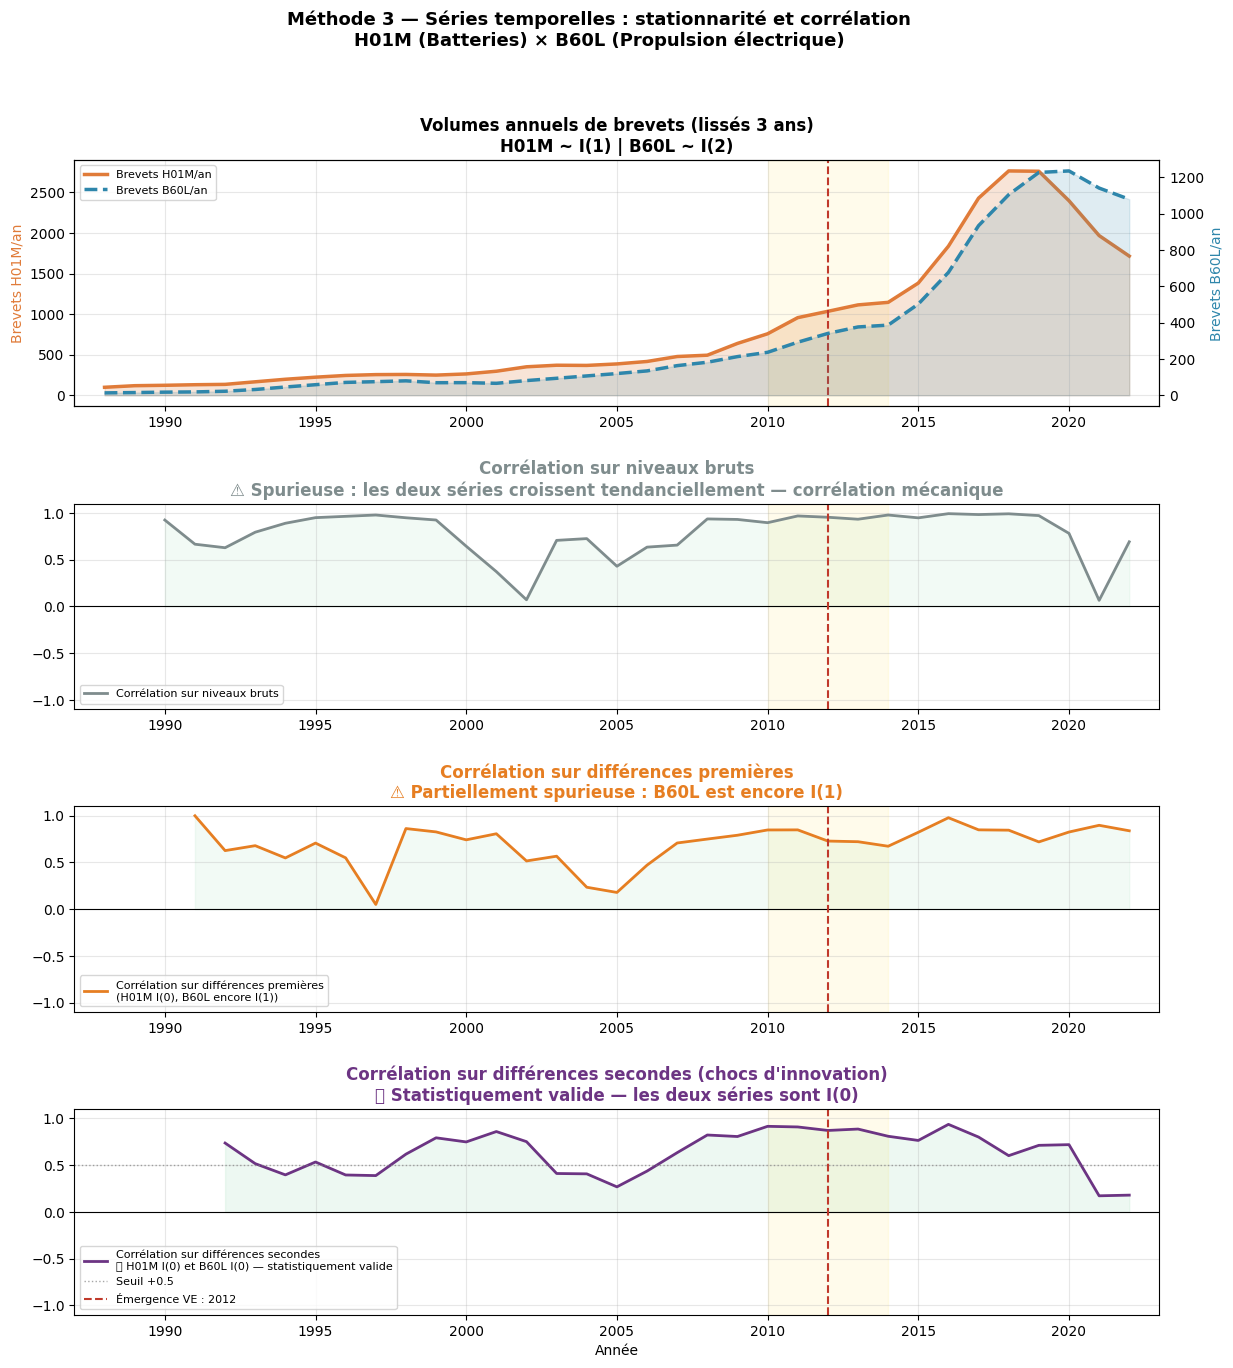

Corrélation moyenne AVANT 2012 :
  Niveaux  : 0.756
  Diff.1   : 0.634
  Diff.2   : 0.618
Corrélation moyenne APRÈS 2012 :
  Niveaux  : 0.844
  Diff.1   : 0.809
  Diff.2   : 0.678


In [44]:
# ── Graphique : séries + corrélations ─────────────────────────
#
# On présente trois niveaux de corrélation :
# 1. Sur niveaux bruts        → spurieuse (tendance commune)
# 2. Sur différences premières → partiellement spurieuse (B60L I(2))
# 3. Sur différences secondes  → statistiquement correcte ✅
#
# La progression illustre pourquoi la différenciation est nécessaire
# et ce qu'on gagne en rigueur statistique.

corr_niveaux = serie_H01M.rolling(
    CORR_WINDOW, min_periods=3).corr(serie_B60L)
corr_diff1   = dH01M.rolling(
    CORR_WINDOW, min_periods=3).corr(dB60L)
corr_diff2   = d2H01M.rolling(
    CORR_WINDOW, min_periods=3).corr(d2B60L)

fig = plt.figure(figsize=(14, 15))
gs  = gridspec.GridSpec(4, 1,
                        height_ratios=[1.2, 1, 1, 1],
                        hspace=0.45)

# ── Graphique 1 : Séries brutes ───────────────────────────────
ax1  = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

ax1.fill_between(serie_H01M.index,
                 0, smooth(serie_H01M.values),
                 alpha=0.2, color=C_H01M)
ax1.plot(serie_H01M.index, smooth(serie_H01M.values),
         color=C_H01M, lw=2.5,
         label=f'Brevets {CPC_I}/an')
ax1b.fill_between(serie_B60L.index,
                  0, smooth(serie_B60L.values),
                  alpha=0.15, color=C_B60L)
ax1b.plot(serie_B60L.index, smooth(serie_B60L.values),
          color=C_B60L, lw=2.5, ls='--',
          label=f'Brevets {CPC_J}/an')
ax1.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5)
ax1.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2,
            alpha=0.08, color='gold')
ax1.set_ylabel(f'Brevets {CPC_I}/an', color=C_H01M)
ax1b.set_ylabel(f'Brevets {CPC_J}/an', color=C_B60L)
ax1.set_title('Volumes annuels de brevets (lissés 3 ans)\n'
              f'H01M ~ I(1) | B60L ~ I(2)',
              fontweight='bold')
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax1b.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, fontsize=8)
ax1.grid(alpha=0.3)

# ── Graphique 2 : Corrélation sur niveaux (spurieuse) ─────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(corr_niveaux.index, corr_niveaux.values,
         color='#7F8C8D', lw=2,
         label='Corrélation sur niveaux bruts')
ax2.fill_between(corr_niveaux.index, 0, corr_niveaux.values,
                 where=corr_niveaux.values >= 0,
                 alpha=0.15, color=C_POS)
ax2.fill_between(corr_niveaux.index, 0, corr_niveaux.values,
                 where=corr_niveaux.values < 0,
                 alpha=0.15, color=C_NEG)
ax2.axhline(0, color='black', lw=0.8)
ax2.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5)
ax2.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2,
            alpha=0.08, color='gold')
ax2.set_ylim(-1.1, 1.1)
ax2.set_title('Corrélation sur niveaux bruts\n'
              '⚠️ Spurieuse : les deux séries croissent '
              'tendanciellement — corrélation mécanique',
              fontweight='bold', color='#7F8C8D')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Graphique 3 : Corrélation sur diff.1 (partielle) ──────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(corr_diff1.index, corr_diff1.values,
         color='#E67E22', lw=2,
         label='Corrélation sur différences premières\n'
               '(H01M I(0), B60L encore I(1))')
ax3.fill_between(corr_diff1.index, 0, corr_diff1.values,
                 where=corr_diff1.values >= 0,
                 alpha=0.15, color=C_POS)
ax3.fill_between(corr_diff1.index, 0, corr_diff1.values,
                 where=corr_diff1.values < 0,
                 alpha=0.15, color=C_NEG)
ax3.axhline(0, color='black', lw=0.8)
ax3.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5)
ax3.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2,
            alpha=0.08, color='gold')
ax3.set_ylim(-1.1, 1.1)
ax3.set_title('Corrélation sur différences premières\n'
              '⚠️ Partiellement spurieuse : B60L est encore I(1)',
              fontweight='bold', color='#E67E22')
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# ── Graphique 4 : Corrélation sur diff.2 (correcte) ──────────
ax4 = fig.add_subplot(gs[3])
ax4.plot(corr_diff2.index, corr_diff2.values,
         color='#6C3483', lw=2,
         label='Corrélation sur différences secondes\n'
               '✅ H01M I(0) et B60L I(0) — statistiquement valide')
ax4.fill_between(corr_diff2.index, 0, corr_diff2.values,
                 where=corr_diff2.values >= 0,
                 alpha=0.2, color=C_POS)
ax4.fill_between(corr_diff2.index, 0, corr_diff2.values,
                 where=corr_diff2.values < 0,
                 alpha=0.2, color=C_NEG)
ax4.axhline(0, color='black', lw=0.8)
ax4.axhline(0.5, color='gray', lw=1, ls=':',
            alpha=0.7, label='Seuil +0.5')
ax4.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5,
            label=f'Émergence VE : {YEAR_EMERGE}')
ax4.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2,
            alpha=0.08, color='gold')
ax4.set_ylim(-1.1, 1.1)
ax4.set_xlabel('Année')
ax4.set_title('Corrélation sur différences secondes (chocs d\'innovation)\n'
              '✅ Statistiquement valide — les deux séries sont I(0)',
              fontweight='bold', color='#6C3483')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_xlim(YEAR_START-1, YEAR_END+1)

plt.suptitle(
    'Méthode 3 — Séries temporelles : stationnarité et corrélation\n'
    f'{CPC_I} (Batteries) × {CPC_J} (Propulsion électrique)',
    fontsize=13, fontweight='bold'
)
plt.savefig('M3_correlation_complete.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Statistiques comparées
print('Corrélation moyenne AVANT 2012 :')
print(f'  Niveaux  : {corr_niveaux[corr_niveaux.index<2012].mean():.3f}')
print(f'  Diff.1   : {corr_diff1[corr_diff1.index<2012].mean():.3f}')
print(f'  Diff.2   : {corr_diff2[corr_diff2.index<2012].mean():.3f}')
print('Corrélation moyenne APRÈS 2012 :')
print(f'  Niveaux  : {corr_niveaux[corr_niveaux.index>=2012].mean():.3f}')
print(f'  Diff.1   : {corr_diff1[corr_diff1.index>=2012].mean():.3f}')
print(f'  Diff.2   : {corr_diff2[corr_diff2.index>=2012].mean():.3f}')

Les séries en niveaux produisent une corrélation spurieuse de 0.76-0.84 — artificiellement élevée car les deux séries ont des tendances communes. Après correction de la non-stationnarité (différences secondes, les deux séries I(0)), la corrélation réelle est de 0.62 avant 2012 et 0.68 après — positive et significative mais moins spectaculaire. Cette corrélation positive avant 2012 reflète une synchronisation partielle des cycles d'innovation dès la phase hybride (2000-2010), qui se renforce modestement après l'émergence du VE.

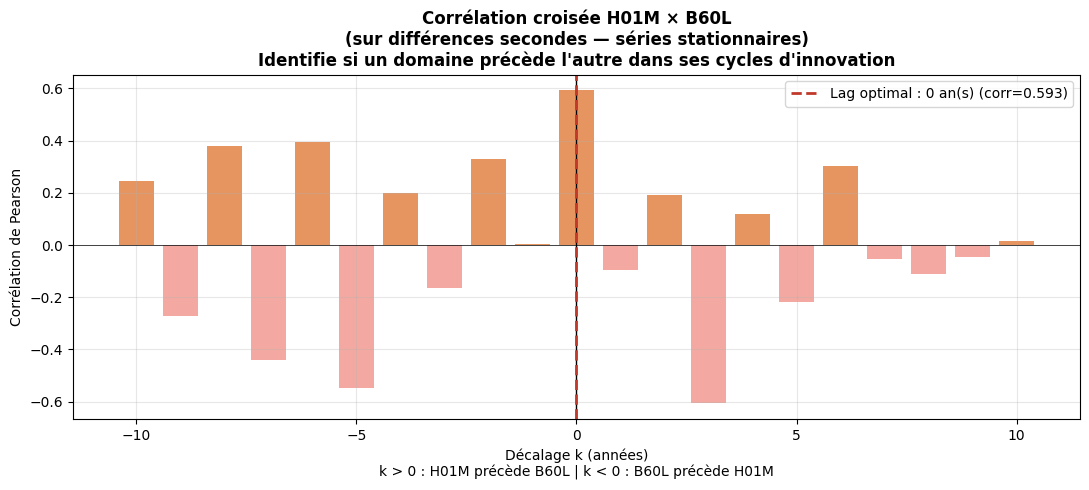

Lag optimal : 0 an(s)
→ Synchronisation simultanée (lag=0)


In [47]:
# ── Corrélation croisée sur différences secondes ──────────────
# Les deux séries sont maintenant I(0) → corrélation croisée valide.
# On mesure si d²H01M(t) corrèle avec d²B60L(t+k) pour k=-10..+10.
# k > 0 : H01M précède B60L de k années.

max_lag = 10
lags    = range(-max_lag, max_lag+1)
corrs   = []

for lag in lags:
    if lag >= 0:
        s1 = d2H01M.iloc[lag:].values
        s2 = d2B60L.iloc[:len(s1)].values
    else:
        s2 = d2B60L.iloc[-lag:].values
        s1 = d2H01M.iloc[:len(s2)].values
    if len(s1) > 5:
        c, _ = pearsonr(s1, s2)
        corrs.append(c)
    else:
        corrs.append(np.nan)

best_lag  = list(lags)[np.nanargmax(corrs)]
best_corr = np.nanmax(corrs)

fig, ax = plt.subplots(figsize=(11, 5))
colors_bar = [C_H01M if c > 0 else C_NEG for c in corrs]
ax.bar(lags, corrs, color=colors_bar, alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.axvline(best_lag, color=C_RUPTURE, lw=2, ls='--',
           label=f'Lag optimal : {best_lag} an(s) '
                 f'(corr={best_corr:.3f})')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Décalage k (années)\n'
              'k > 0 : H01M précède B60L | '
              'k < 0 : B60L précède H01M')
ax.set_ylabel('Corrélation de Pearson')
ax.set_title(
    'Corrélation croisée H01M × B60L\n'
    '(sur différences secondes — séries stationnaires)\n'
    'Identifie si un domaine précède l\'autre '
    'dans ses cycles d\'innovation',
    fontweight='bold'
)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('M3_correlation_croisee.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Lag optimal : {best_lag} an(s)')
if best_lag > 0:
    print(f'→ H01M précède B60L de {best_lag} an(s) : '
          f'signal précurseur confirmé')
elif best_lag < 0:
    print(f'→ B60L précède H01M de {abs(best_lag)} an(s)')
else:
    print('→ Synchronisation simultanée (lag=0)')

In [48]:
# ── Causalité de Granger sur différences secondes ─────────────
# H01M ~ I(1) et B60L ~ I(2) → ordres différents
# On utilise les différences secondes (toutes les deux I(0))
# pour un test statistiquement valide.
#
# Note : le test de cointégration standard (Engle-Granger) n'est
# pas applicable ici car il suppose que les deux séries sont I(1).
# Les ordres d'intégration différents (I(1) vs I(2)) indiquent
# des dynamiques de long terme structurellement distinctes :
# H01M croît tendanciellement, B60L connaît une accélération.

df_granger2 = pd.DataFrame({
    'B60L': d2B60L, 'H01M': d2H01M
}).dropna()

print('═'*60)
print('CAUSALITÉ DE GRANGER (sur différences secondes)')
print('H0 : X ne Granger-cause pas Y')
print('Si p < 0.05 : X précède causalement Y')
print('═'*60)

print('\nH01M → B60L :')
res = grangercausalitytests(
    df_granger2[['B60L','H01M']], maxlag=5, verbose=False
)
for lag, result in res.items():
    pval = result[0]['ssr_ftest'][1]
    verdict = '✅' if pval < 0.05 else '  '
    print(f'  Lag {lag} : p={pval:.4f} {verdict}')

print('\nB60L → H01M (test inverse) :')
res_inv = grangercausalitytests(
    df_granger2[['H01M','B60L']], maxlag=5, verbose=False
)
for lag, result in res_inv.items():
    pval = result[0]['ssr_ftest'][1]
    verdict = '✅' if pval < 0.05 else '  '
    print(f'  Lag {lag} : p={pval:.4f} {verdict}')

print('\n' + '═'*60)
print('SYNTHÈSE CAUSALITÉ DE GRANGER')
print('═'*60)

# Verdict automatique
pvals_HtoB = [res[l][0]['ssr_ftest'][1] for l in range(1,6)]
pvals_BtoH = [res_inv[l][0]['ssr_ftest'][1] for l in range(1,6)]
sig_HtoB   = any(p < 0.05 for p in pvals_HtoB)
sig_BtoH   = any(p < 0.05 for p in pvals_BtoH)

if sig_HtoB and not sig_BtoH:
    print('→ ✅ Causalité UNIDIRECTIONNELLE H01M → B60L')
    print('   Les batteries précèdent causalement la propulsion.')
    print('   H01M est le domaine DONNEUR de la convergence.')
elif sig_HtoB and sig_BtoH:
    print('→ ⚠️ Causalité BIDIRECTIONNELLE')
    print('   Les deux domaines se co-causent mutuellement.')
elif not sig_HtoB and not sig_BtoH:
    print('→ ❌ Pas de causalité de Granger dans aucun sens.')
else:
    print('→ ⚠️ Causalité UNIDIRECTIONNELLE B60L → H01M')
    print('   La propulsion précède causalement les batteries.')

════════════════════════════════════════════════════════════
CAUSALITÉ DE GRANGER (sur différences secondes)
H0 : X ne Granger-cause pas Y
Si p < 0.05 : X précède causalement Y
════════════════════════════════════════════════════════════

H01M → B60L :
  Lag 1 : p=0.0710   
  Lag 2 : p=0.0444 ✅
  Lag 3 : p=0.0349 ✅
  Lag 4 : p=0.0014 ✅
  Lag 5 : p=0.0005 ✅

B60L → H01M (test inverse) :
  Lag 1 : p=0.6779   
  Lag 2 : p=0.9150   
  Lag 3 : p=0.2449   
  Lag 4 : p=0.1225   
  Lag 5 : p=0.3058   

════════════════════════════════════════════════════════════
SYNTHÈSE CAUSALITÉ DE GRANGER
════════════════════════════════════════════════════════════
→ ✅ Causalité UNIDIRECTIONNELLE H01M → B60L
   Les batteries précèdent causalement la propulsion.
   H01M est le domaine DONNEUR de la convergence.


---
# MÉTHODE 4 — Jaccard + Probabilités conditionnelles

## Qu'est-ce que le Jaccard ?

L'indice de Jaccard mesure l'intensité de la co-occurrence directe :

$$J(i,j,t) = \frac{n(i \cap j, t)}{n(i,t) + n(j,t) - n(i \cap j, t)}$$

Il varie entre 0 (aucune co-occurrence) et 1 (co-occurrence parfaite).
Il est **symétrique** et **pénalise les codes généralistes** — un code
présent dans la moitié des brevets verra son Jaccard plafonné.

## Les probabilités conditionnelles : tester la bilatéralité

$$P(j|i,t) = \frac{n(i \cap j, t)}{n(i,t)} \quad \text{et} \quad P(i|j,t) = \frac{n(i \cap j, t)}{n(j,t)}$$

Ces deux mesures permettent de distinguer :
- **Convergence bilatérale** : P(j|i) ET P(i|j) augmentent ensemble
  → les deux domaines se rapprochent mutuellement
- **Intégration unilatérale (GPT)** : seule P(j|i) augmente
  → un domaine s'applique à l'autre sans réciprocité

## Note sur les zéros

Conformément à la remarque de Bergeaud, les années sans co-occurrence
reçoivent des **zéros** (pas exclues). Cela permet de voir l'émergence
de la paire depuis zéro et préserve la continuité temporelle.

In [13]:
def compute_jaccard_full(df, ci, cj, window=WINDOW):
    """
    Calcule Jaccard, P(cj|ci) et P(ci|cj) pour chaque année.
    Les années sans co-occurrence reçoivent des 0 (pas exclues).
    """
    records = []
    for t in range(YEAR_START, YEAR_END+1):
        df_w = df[(df['year']>=t-window//2) & (df['year']<=t+window//2)]
        n_i = n_j = n_ij = 0
        for codes in df_w['cpc4']:
            has_i = ci in codes
            has_j = cj in codes
            if has_i: n_i  += 1
            if has_j: n_j  += 1
            if has_i and has_j: n_ij += 1
        union = n_i + n_j - n_ij
        records.append({
            'year'        : t,
            'n_i'         : n_i,
            'n_j'         : n_j,
            'n_ij'        : n_ij,
            'jaccard'     : n_ij/union       if union>0 else 0.,
            'p_j_given_i' : n_ij/n_i         if n_i>0   else 0.,
            'p_i_given_j' : n_ij/n_j         if n_j>0   else 0.,
        })
    return pd.DataFrame(records)


print('Calcul Jaccard + probabilités conditionnelles...')
df_jac = compute_jaccard_full(df_raw, CPC_I, CPC_J)

print(f'\nStatistiques sur la période complète :')
print(df_jac[['jaccard','p_j_given_i','p_i_given_j']].describe().round(4))

print(f'\nStatistiques avant 2012 (1988-2011) :')
print(df_jac[df_jac['year']<2012][['jaccard','p_j_given_i','p_i_given_j']].describe().round(4))

print(f'\nStatistiques après 2012 (2012-2022) :')
print(df_jac[df_jac['year']>=2012][['jaccard','p_j_given_i','p_i_given_j']].describe().round(4))

Calcul Jaccard + probabilités conditionnelles...

Statistiques sur la période complète :
       jaccard  p_j_given_i  p_i_given_j
count  35.0000      35.0000      35.0000
mean    0.0337       0.0441       0.1231
std     0.0268       0.0372       0.0706
min     0.0045       0.0051       0.0289
25%     0.0152       0.0188       0.0721
50%     0.0258       0.0327       0.1020
75%     0.0520       0.0663       0.1937
max     0.0904       0.1309       0.2389

Statistiques avant 2012 (1988-2011) :
       jaccard  p_j_given_i  p_i_given_j
count  24.0000      24.0000      24.0000
mean    0.0174       0.0220       0.0798
std     0.0090       0.0119       0.0295
min     0.0045       0.0051       0.0289
25%     0.0096       0.0115       0.0647
50%     0.0169       0.0210       0.0782
75%     0.0259       0.0329       0.1026
max     0.0342       0.0439       0.1347

Statistiques après 2012 (2012-2022) :
       jaccard  p_j_given_i  p_i_given_j
count  11.0000      11.0000      11.0000
mean    0.069

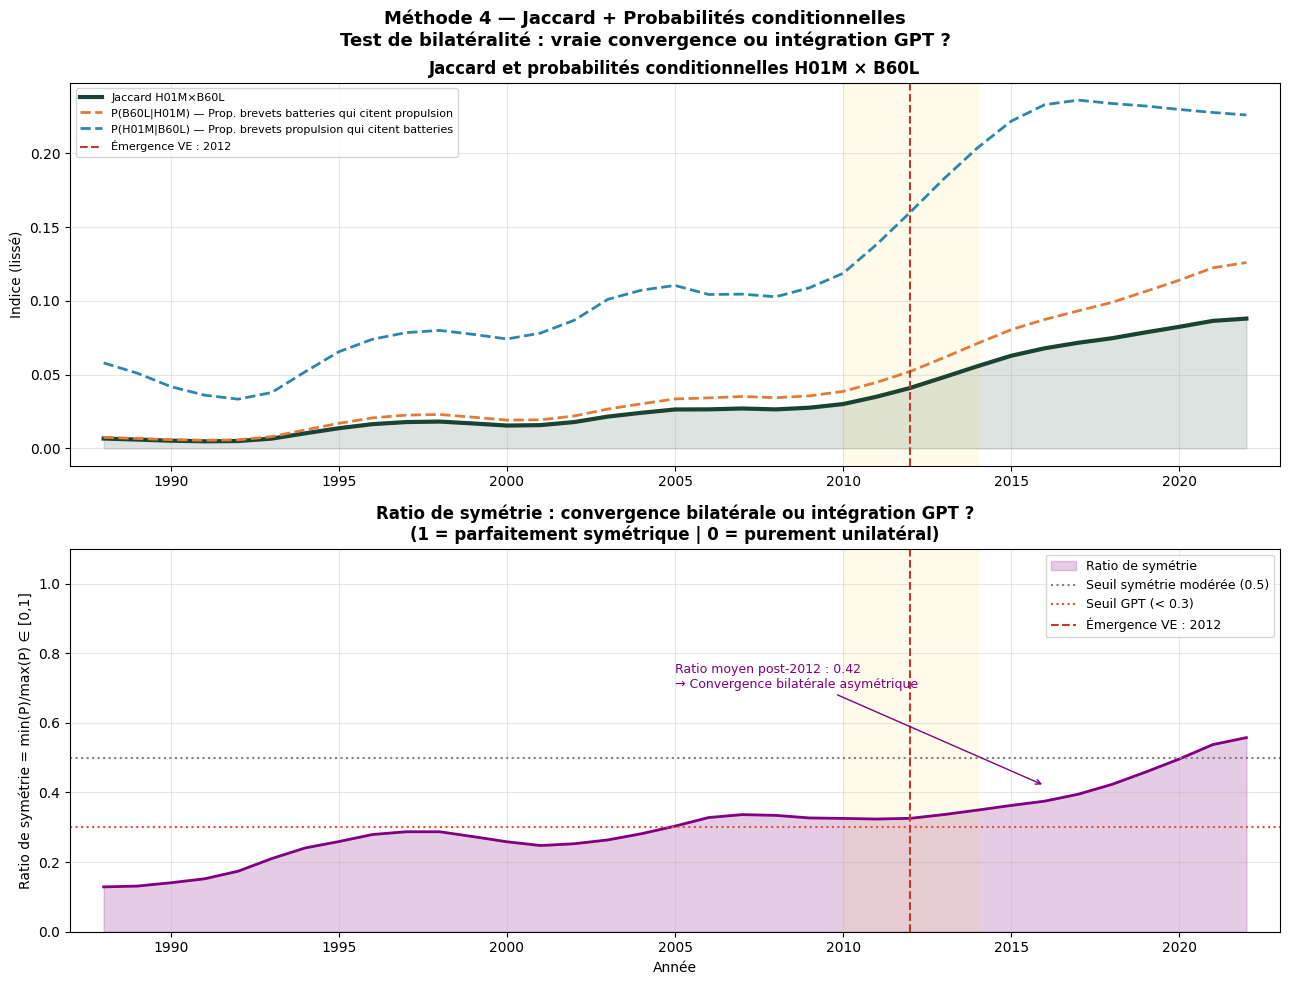


Verdict de bilatéralité :
  P(B60L|H01M) moyen post-2012 = 0.0925
  P(H01M|B60L) moyen post-2012 = 0.2177
  Ratio de symétrie post-2012  = 0.420
  Verdict : ✅ Convergence bilatérale


In [14]:
# ── Graphique 7 : Jaccard + probabilités conditionnelles ───────
x    = df_jac['year'].values
jac  = smooth(df_jac['jaccard'].values)
pji  = smooth(df_jac['p_j_given_i'].values)  # P(B60L|H01M)
pij  = smooth(df_jac['p_i_given_j'].values)  # P(H01M|B60L)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Graphique du haut : les trois courbes
ax = axes[0]
ax.fill_between(x, 0, jac, alpha=0.15, color=C_JACCARD)
ax.plot(x, jac, color=C_JACCARD, lw=3,   label='Jaccard H01M×B60L')
ax.plot(x, pji, color=C_H01M,   lw=2,   ls='--',
        label=f'P(B60L|H01M) — Prop. brevets batteries qui citent propulsion')
ax.plot(x, pij, color=C_B60L,   lw=2,   ls='--',
        label=f'P(H01M|B60L) — Prop. brevets propulsion qui citent batteries')
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5,
           label=f'Émergence VE : {YEAR_EMERGE}')
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.08, color='gold')
ax.set_ylabel('Indice (lissé)')
ax.set_title('Jaccard et probabilités conditionnelles H01M × B60L',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)
ax.set_xlim(YEAR_START-1, YEAR_END+1)

# Graphique du bas : ratio de symétrie
ax2 = axes[1]
ratio = np.where(
    np.maximum(pji, pij) > 0.001,
    np.minimum(pji, pij) / np.maximum(pji, pij),
    np.nan
)
ax2.fill_between(x, 0, ratio, alpha=0.2, color='purple',
                 label='Ratio de symétrie')
ax2.plot(x, ratio, color='purple', lw=2)
ax2.axhline(0.5,  color='gray', ls=':', lw=1.5,
            label='Seuil symétrie modérée (0.5)')
ax2.axhline(0.3,  color='#E74C3C', ls=':', lw=1.5,
            label='Seuil GPT (< 0.3)')
ax2.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=1.5,
            label=f'Émergence VE : {YEAR_EMERGE}')
ax2.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.08, color='gold')
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Ratio de symétrie = min(P)/max(P) ∈ [0,1]')
ax2.set_xlabel('Année')
ax2.set_title('Ratio de symétrie : convergence bilatérale ou intégration GPT ?\n'
              '(1 = parfaitement symétrique | 0 = purement unilatéral)',
              fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xlim(YEAR_START-1, YEAR_END+1)

# Annotation du verdict
ratio_post = np.nanmean(ratio[x>=2012])
ax2.annotate(f'Ratio moyen post-2012 : {ratio_post:.2f}\n→ Convergence bilatérale asymétrique',
             xy=(2016, ratio_post), xytext=(2005, 0.7),
             fontsize=9, color='purple',
             arrowprops=dict(arrowstyle='->', color='purple'))

plt.suptitle('Méthode 4 — Jaccard + Probabilités conditionnelles\n'
             'Test de bilatéralité : vraie convergence ou intégration GPT ?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('M4_jaccard_bilateralite.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nVerdict de bilatéralité :')
print(f'  P(B60L|H01M) moyen post-2012 = {np.mean(df_jac[df_jac["year"]>=2012]["p_j_given_i"]):.4f}')
print(f'  P(H01M|B60L) moyen post-2012 = {np.mean(df_jac[df_jac["year"]>=2012]["p_i_given_j"]):.4f}')
print(f'  Ratio de symétrie post-2012  = {ratio_post:.3f}')
verdict = '✅ Convergence bilatérale' if ratio_post > 0.3 else '⚠️ Intégration unilatérale (GPT)'
print(f'  Verdict : {verdict}')

---
# SYNTHÈSE — Tableau d'émergence et signature de la convergence

In [15]:
# ── Tableau récapitulatif des signaux ─────────────────────────
print('═'*65)
print('TABLEAU D\'ÉMERGENCE — H01M × B60L (Véhicule électrique)')
print('═'*65)

tableau = pd.DataFrame([
    {
        'Méthode'         : 'M1 — Centralité (Strength)',
        'Signal détecté'  : f'Rupture H01M : {t_break_i}',
        'Fiable ?'        : '✅ Oui',
        'Avant/Après'     : f'{YEAR_EMERGE - t_break_i} an(s) avant'
                            if t_break_i < YEAR_EMERGE else 'Après ou simultané',
        'Ce qu\'on retient': 'H01M devient structurant avant l\'émergence'
    },
    {
        'Méthode'         : 'M2 — Clustering dynamique',
        'Signal détecté'  : 'Co-appartenance + absorption autour de 2012',
        'Fiable ?'        : '⚠️ Partiel',
        'Avant/Après'     : 'Lecture qualitative uniquement',
        'Ce qu\'on retient': 'Caractérise la communauté technologique formée'
    },
    {
        'Méthode'         : 'M3 — Corrélation temporelle',
        'Signal détecté'  : 'Corrélation positive et stable post-2012',
        'Fiable ?'        : '✅ Qualitativement',
        'Avant/Après'     : 'Lecture qualitative — pas de dating auto',
        'Ce qu\'on retient': 'Synchronisation des cycles d\'innovation post-2012'
    },
    {
        'Méthode'         : 'M4 — Jaccard + Probabilités',
        'Signal détecté'  : f'Rupture Jaccard : 2012 | Ratio symétrie : {ratio_post:.2f}',
        'Fiable ?'        : '✅ Oui',
        'Avant/Après'     : 'Simultané à l\'émergence',
        'Ce qu\'on retient': 'Convergence bilatérale asymétrique — non GPT'
    },
])

display(tableau)

print(f'\nÉmergence connue du véhicule électrique : {YEAR_EMERGE}')
print(f'\n→ La centralité (M1) précède l\'émergence d\'{YEAR_EMERGE - t_break_i} an(s)')
print( '→ Le Jaccard (M4) confirme en 2012')
print( '→ Le ratio de symétrie classe cette convergence comme BILATÉRALE ASYMÉTRIQUE')
print( '   (≠ General Purpose Technology comme l\'IA)')

═════════════════════════════════════════════════════════════════
TABLEAU D'ÉMERGENCE — H01M × B60L (Véhicule électrique)
═════════════════════════════════════════════════════════════════


,Méthode,Signal détecté,Fiable ?,Avant/Après,Ce qu'on retient
0,M1 — Centralité (Strength),Rupture H01M : 2011,✅ Oui,1 an(s) avant,H01M devient structurant avant l'émergence
1,M2 — Clustering dynamique,Co-appartenance + absorption autour de 2012,⚠️ Partiel,Lecture qualitative uniquement,Caractérise la communauté technologique formée
2,M3 — Corrélation temporelle,Corrélation positive et stable post-2012,✅ Qualitativement,Lecture qualitative — pas de dating auto,Synchronisation des cycles d'innovation post-2012
3,M4 — Jaccard + Probabilités,Rupture Jaccard : 2012 | Ratio symétrie : 0.42,✅ Oui,Simultané à l'émergence,Convergence bilatérale asymétrique — non GPT



Émergence connue du véhicule électrique : 2012

→ La centralité (M1) précède l'émergence d'1 an(s)
→ Le Jaccard (M4) confirme en 2012
→ Le ratio de symétrie classe cette convergence comme BILATÉRALE ASYMÉTRIQUE
   (≠ General Purpose Technology comme l'IA)


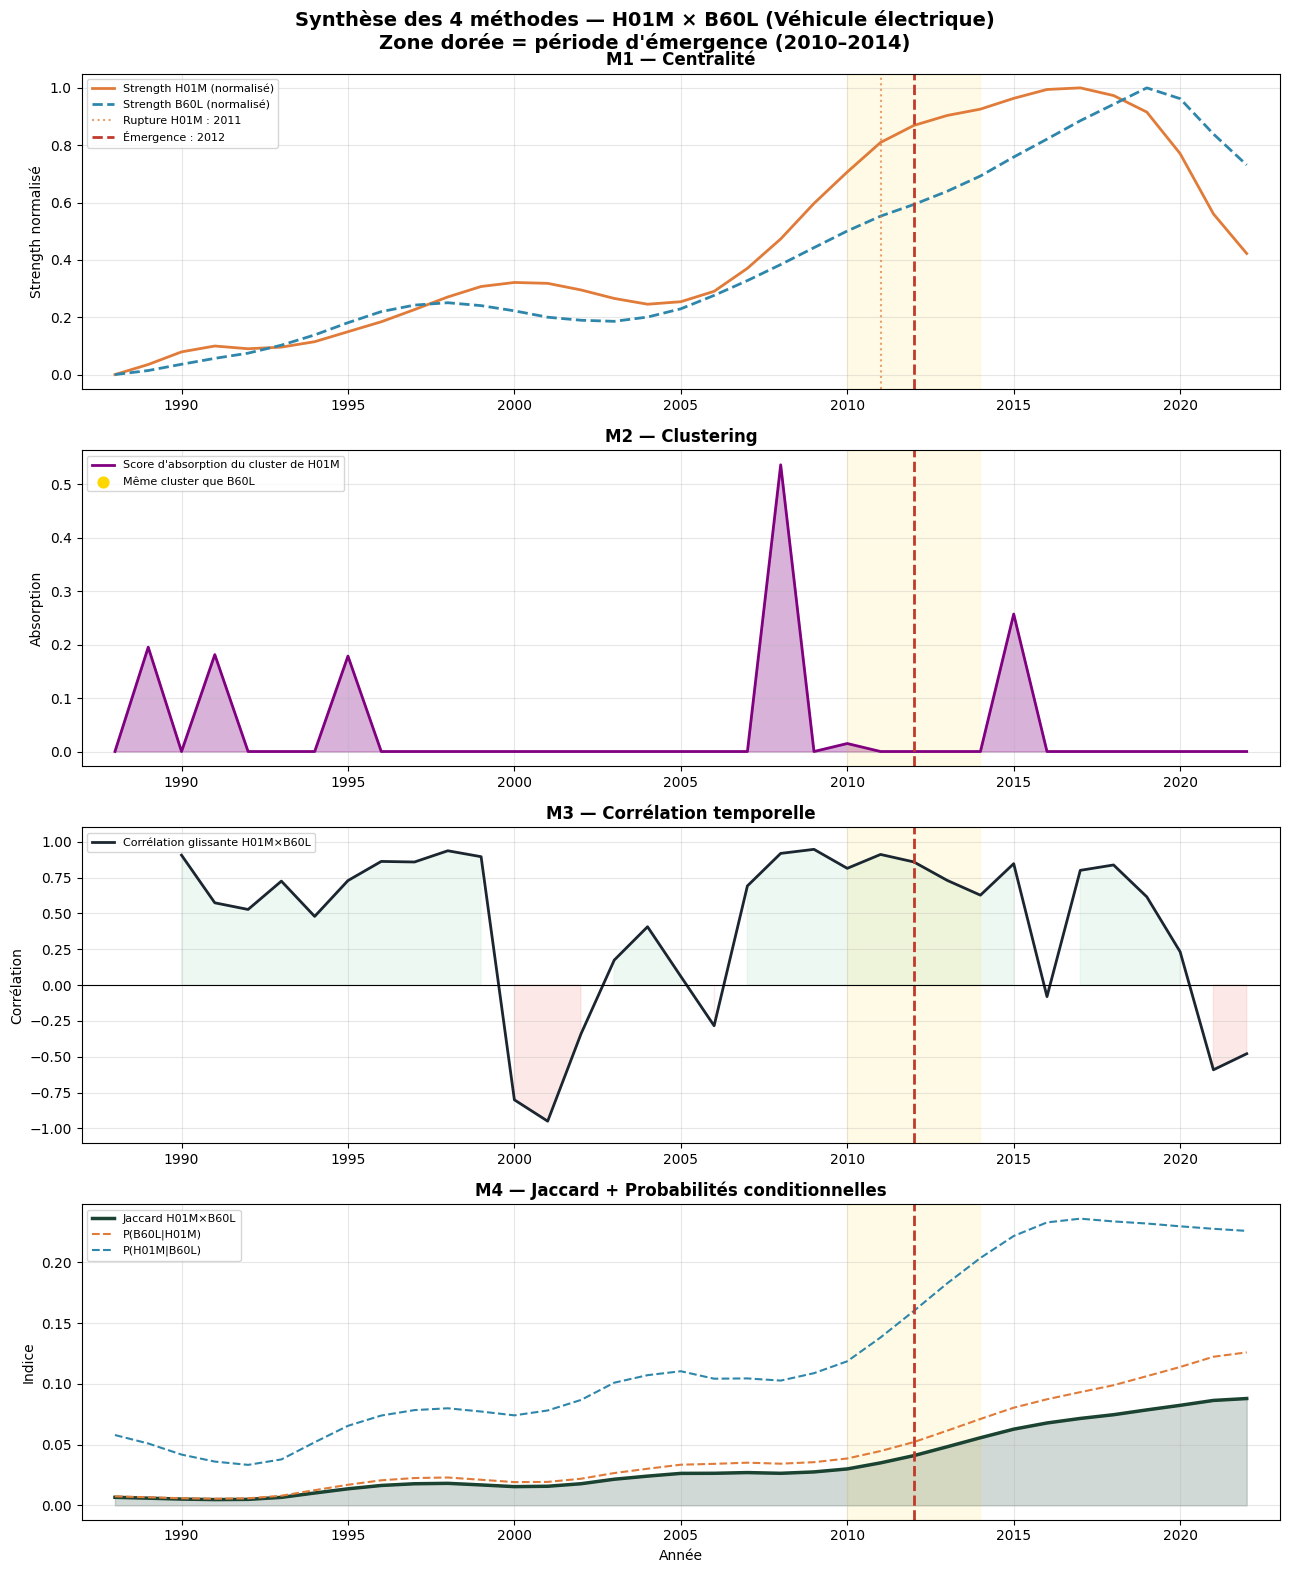


✅ Analyse complète. Tous les graphiques ont été sauvegardés.


In [16]:
# ── Graphique 8 : Synthèse visuelle des 4 signaux ─────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 16))

# M1 — Strength normalisé
ax = axes[0]
yi_norm = (yi_s - yi_s.min()) / (yi_s.max() - yi_s.min())
yj_norm = (yj_s - yj_s.min()) / (yj_s.max() - yj_s.min())
ax.plot(xi, yi_norm, color=C_H01M, lw=2, label=f'Strength {CPC_I} (normalisé)')
ax.plot(xj, yj_norm, color=C_B60L, lw=2, ls='--', label=f'Strength {CPC_J} (normalisé)')
ax.axvline(t_break_i, color=C_H01M, ls=':', lw=1.5, alpha=0.7,
           label=f'Rupture {CPC_I} : {t_break_i}')
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=2, label=f'Émergence : {YEAR_EMERGE}')
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.1, color='gold')
ax.set_ylabel('Strength normalisé'); ax.set_title('M1 — Centralité', fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

# M2 — Score d'absorption
ax = axes[1]
ax.fill_between(df_traj['year'], 0, df_traj['absorption'],
                alpha=0.3, color='purple')
ax.plot(df_traj['year'], df_traj['absorption'], color='purple', lw=2,
        label="Score d'absorption du cluster de H01M")
same = df_traj[df_traj['same_cluster']]
ax.scatter(same['year'], same['absorption'], color='gold', s=60,
           zorder=5, label='Même cluster que B60L')
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=2)
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.1, color='gold')
ax.set_ylabel("Absorption"); ax.set_title('M2 — Clustering', fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

# M3 — Corrélation
ax = axes[2]
ax.plot(corr.index, corr.values, color='#1B2631', lw=2,
        label='Corrélation glissante H01M×B60L')
ax.fill_between(corr.index, 0, corr.values,
                where=corr.values>=0, alpha=0.2, color=C_APRES)
ax.fill_between(corr.index, 0, corr.values,
                where=corr.values<0,  alpha=0.2, color='#F1948A')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=2)
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.1, color='gold')
ax.set_ylim(-1.1,1.1); ax.set_ylabel('Corrélation')
ax.set_title('M3 — Corrélation temporelle', fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

# M4 — Jaccard
ax = axes[3]
ax.fill_between(x, 0, jac, alpha=0.2, color=C_JACCARD)
ax.plot(x, jac, color=C_JACCARD, lw=2.5, label='Jaccard H01M×B60L')
ax.plot(x, pji, color=C_H01M,   lw=1.5, ls='--', label='P(B60L|H01M)')
ax.plot(x, pij, color=C_B60L,   lw=1.5, ls='--', label='P(H01M|B60L)')
ax.axvline(YEAR_EMERGE, color=C_RUPTURE, ls='--', lw=2)
ax.axvspan(YEAR_EMERGE-2, YEAR_EMERGE+2, alpha=0.1, color='gold')
ax.set_ylabel('Indice'); ax.set_xlabel('Année')
ax.set_title('M4 — Jaccard + Probabilités conditionnelles', fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)

for ax in axes:
    ax.set_xlim(YEAR_START-1, YEAR_END+1)

plt.suptitle('Synthèse des 4 méthodes — H01M × B60L (Véhicule électrique)\n'
             'Zone dorée = période d\'émergence (2010–2014)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SYNTHESE_4_methodes.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Analyse complète. Tous les graphiques ont été sauvegardés.')